# 手动特征工程
统一的特征聚合、特征选择过程

## 引言

手动特征工程是繁琐的，通常依赖领域知识。
我们尽可能注入更多特征， 由模型识别。
我们会也会使用一些自动化特征工具，
会使用pca等降维

在第一个notebook中，使用了application数据集构建，为了提高分数，引入更多数据特征。

在这个notebook中，我们描述了**特征聚合和特征选择的统一处理**过程，这不涉及什么领域知识。

会大量使用pandas操作
- groupby
- agg 对分组计算
- merge 汇总
- rename 列
- 

会涉及到很多特征阶段。我们必须进行一些存储。 我们通过feather命名区分：
命名规则：`[阶段]_[来源表]_[处理程度]`
- `01_app_train_raw.feather` : 01原始， 主表，； 仅做了onehot类型编
- `02_prev_app_agg.feather`: 02子表聚合， ； agg特征
- `03_bureau_cleaned.feather`: 03子表 ： 特征选择剔除：missing、高corr
- `	04_merged_v1.feather` : 04 合并子表：
- `04_main_bureau_prev_combined.feather` 

此外，由于涉及大量内存复制和计算机的能力，我需要及时回收掉那些大变量

在第一部分中，通过引入*bureau*, *bureau_balance*表，我们详细阐述了统一的特征处理
- 增加特征：聚合ID、分类、数字特征，多层聚合
- 去掉特征：高missing、高相关的特征。
  
在处理完成后，我们会与*application_train/test*主表merge，保存特征方便后续使用


在第二部分中，引入剩余的4个表，我们为这个统一的特征处理过程设置了`agg_numeric`,`agg_categorical`,`get_high_corr_columns`,`get_high_missing_columns`,`feature_select` 等函数，这加快了处理速度

在完成所有表特征处理后，我们将他们合起来。进行model，看看新特征的效果。确实，很多新特征变成重要的分类特征，这也使得分数提升了

## 导入包

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.style.use('fivethirtyeight')

## 第一部分 

第一部分主要做两件事：
- 引入bureau和bureau_balance特征，描述用户之前在homecredit贷款情况
- 描述了手动特征的一般工程
  - 分类特征：
  - id特征： count计数
  - 数值统计特征：   

### bureau
- 产出 bureau_agg

In [4]:
train = pd.read_feather('checkpoints/01_train_app_base.feather')
test = pd.read_feather('checkpoints/01_test_app_base.feather')
print(train.shape, test.shape)

(307511, 243) (48744, 242)


In [5]:
bureau = pd.read_csv('data/bureau.csv')
bureau.shape


(1716428, 17)

#### SK_ID_BUREAU计数
- 产生了`bureau_previous_loan_counts`特征集

In [6]:
bureau_previous_loan_counts = bureau.groupby(by='SK_ID_CURR', as_index= False)['SK_ID_BUREAU'].count().rename(columns = {
    'SK_ID_BUREAU': 'bureau_previous_loan_counts'
})

In [7]:
bureau_previous_loan_counts.sort_values(by='bureau_previous_loan_counts', ascending=False)

,SK_ID_CURR,bureau_previous_loan_counts
17942,120860,116
59911,169704,94
187259,318065,78
130327,251643,61
279405,425396,60
...,...,...
19,100025,1
49,100061,1
39,100048,1
185447,315945,1


In [8]:
bureau_previous_loan_counts.shape

(305811, 2)

Assessing Usefulness of New Variable with r value

In [9]:
train[['SK_ID_CURR','TARGET']]

,SK_ID_CURR,TARGET
0,100002,1
1,100003,0
2,100004,0
3,100006,0
4,100007,0
...,...,...
307506,456251,0
307507,456252,0
307508,456253,0
307509,456254,1


In [10]:
bureau_previous_loan_counts_plot = pd.merge(train[['SK_ID_CURR','TARGET']], bureau_previous_loan_counts, on='SK_ID_CURR', how='left')
bureau_previous_loan_counts_plot = bureau_previous_loan_counts_plot.fillna(0)
bureau_previous_loan_counts_plot

,SK_ID_CURR,TARGET,bureau_previous_loan_counts
0,100002,1,8.0
1,100003,0,4.0
2,100004,0,2.0
3,100006,0,0.0
4,100007,0,1.0
...,...,...,...
307506,456251,0,0.0
307507,456252,0,0.0
307508,456253,0,4.0
307509,456254,1,1.0


Text(0.5, 1.0, 'bureau_previous_loan_counts distribution')

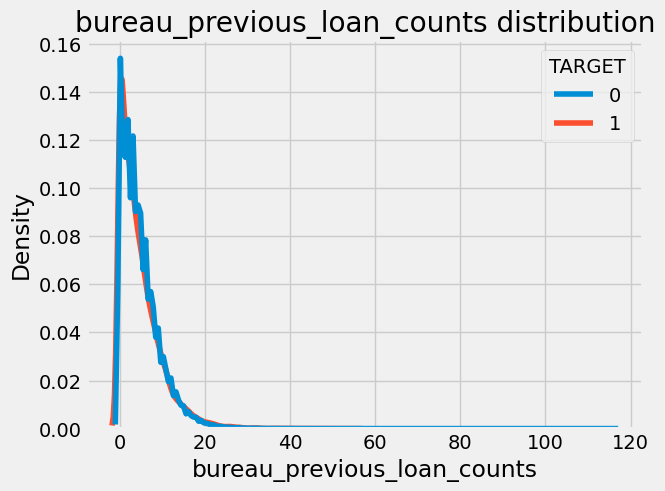

In [11]:
sns.kdeplot(
    data= bureau_previous_loan_counts_plot,
    x = 'bureau_previous_loan_counts',
    hue = 'TARGET',
    common_norm = False
)
plt.title('bureau_previous_loan_counts distribution')


几乎是同分布的，没什么区别

In [12]:
corr = np.corrcoef(bureau_previous_loan_counts_plot['bureau_previous_loan_counts'],
     bureau_previous_loan_counts_plot['TARGET'])[0, 1]
print(f'correlations bureau_previous_loan_counts and TARGET is {corr}')

correlations bureau_previous_loan_counts and TARGET is -0.010019715670684074


In [13]:
del bureau_previous_loan_counts_plot
gc.collect()

182

相关性很低，没有进入之前的top5. 我们没有得到什么信息。

#### Agg the numeric volumns
- 我们产生了`bureau_numeric_agg` 新的特征集

In [14]:
bureau.dtypes

SK_ID_CURR                  int64
SK_ID_BUREAU                int64
CREDIT_ACTIVE                 str
CREDIT_CURRENCY               str
DAYS_CREDIT                 int64
CREDIT_DAY_OVERDUE          int64
DAYS_CREDIT_ENDDATE       float64
DAYS_ENDDATE_FACT         float64
AMT_CREDIT_MAX_OVERDUE    float64
CNT_CREDIT_PROLONG          int64
AMT_CREDIT_SUM            float64
AMT_CREDIT_SUM_DEBT       float64
AMT_CREDIT_SUM_LIMIT      float64
AMT_CREDIT_SUM_OVERDUE    float64
CREDIT_TYPE                   str
DAYS_CREDIT_UPDATE          int64
AMT_ANNUITY               float64
dtype: object

In [15]:
bureau_numeric = bureau.select_dtypes(exclude=['str'])

In [16]:
bureau_numeric_agg = bureau_numeric.drop(columns=['SK_ID_BUREAU']).groupby(by='SK_ID_CURR', as_index=False).agg(
    ['min','mean',  'max', 'sum']
)
bureau_numeric_agg

SK_ID_CURR DAYS_CREDIT                           CREDIT_DAY_OVERDUE  \
                          min         mean   max    sum                min   
0          100001       -1572  -735.000000   -49  -5145                  0   
1          100002       -1437  -874.000000  -103  -6992                  0   
2          100003       -2586 -1400.750000  -606  -5603                  0   
3          100004       -1326  -867.000000  -408  -1734                  0   
4          100005        -373  -190.666667   -62   -572                  0   
...           ...         ...          ...   ...    ...                ...   
305806     456249       -2713 -1667.076923  -483 -21672                  0   
305807     456250       -1002  -862.000000  -760  -2586                  0   
305808     456253        -919  -867.500000  -713  -3470                  0   
305809     456254       -1104 -1104.000000 -1104  -1104                  0   
305810     456255       -2337 -1089.454545  -363 -11984                  0   

                    DAYS_CREDIT_ENDDATE  ... AMT_CREDIT_SUM_OVERDUE       \
       mean max sum                 min  ...                    max  sum   
0       0.0   0   0             -1329.0  ...                    0.0  0.0   
1       0.0   0   0             -1072.0  ...                    0.0  0.0   
2       0.0   0   0             -2434.0  ...                    0.0  0.0   
3       0.0   0   0              -595.0  ...                    0.0  0.0   
4       0.0   0   0              -128.0  ...                    0.0  0.0   
...     ...  ..  ..                 ...  ...                    ...  ...   
305806  0.0   0   0             -2499.0  ...                    0.0  0.0   
305807  0.0   0   0              -272.0  ...                    0.0  0.0   
305808  0.0   0   0              -189.0  ...                    0.0  0.0   
305809  0.0   0   0              -859.0  ...                    0.0  0.0   
305810  0.0   0   0             -1243.0  ...                    0.0  0.0   

       DAYS_CREDIT_UPDATE                          AMT_ANNUITY                 \
                      min         mean  max    sum         min           mean   
0                    -155   -93.142857   -6   -652       0.000    3545.357143   
1                   -1185  -499.875000   -7  -3999       0.000       0.000000   
2                   -2131  -816.000000  -43  -3264         NaN            NaN   
3                    -682  -532.000000 -382  -1064         NaN            NaN   
4                    -121   -54.333333  -11   -163       0.000    1420.500000   
...                   ...          ...  ...    ...         ...            ...   
305806              -2498 -1064.538462  -12 -13839         NaN            NaN   
305807               -127   -60.333333  -23   -181   27757.395  154567.965000   
305808               -701  -253.250000   -5  -1013   58369.500   58369.500000   
305809               -401  -401.000000 -401   -401       0.000       0.000000   
305810              -1621  -531.090909   -8  -5842       0.000    1081.500000   

                              
             max         sum  
0        10822.5   24817.500  
1            0.0       0.000  
2            NaN       0.000  
3            NaN       0.000  
4         4261.5    4261.500  
...          ...         ...  
305806       NaN       0.000  
305807  384147.0  463703.895  
305808   58369.5  175108.500  
305809       0.0       0.000  
305810    3244.5    9733.500  

[305811 rows x 49 columns]

我们把多层索引平铺

In [17]:
bureau_numeric_agg.columns = [
    f"bureau_{col[0]}_{col[1]}" if col[1] != "" else col[0] 
    for col in bureau_numeric_agg.columns.values
]
bureau_numeric_agg

,SK_ID_CURR,bureau_DAYS_CREDIT_min,bureau_DAYS_CREDIT_mean,bureau_DAYS_CREDIT_max,bureau_DAYS_CREDIT_sum,bureau_CREDIT_DAY_OVERDUE_min,bureau_CREDIT_DAY_OVERDUE_mean,bureau_CREDIT_DAY_OVERDUE_max,bureau_CREDIT_DAY_OVERDUE_sum,bureau_DAYS_CREDIT_ENDDATE_min,...,bureau_AMT_CREDIT_SUM_OVERDUE_max,bureau_AMT_CREDIT_SUM_OVERDUE_sum,bureau_DAYS_CREDIT_UPDATE_min,bureau_DAYS_CREDIT_UPDATE_mean,bureau_DAYS_CREDIT_UPDATE_max,bureau_DAYS_CREDIT_UPDATE_sum,bureau_AMT_ANNUITY_min,bureau_AMT_ANNUITY_mean,bureau_AMT_ANNUITY_max,bureau_AMT_ANNUITY_sum
0,100001,-1572,-735.000000,-49,-5145,0,0.0,0,0,-1329.0,...,0.0,0.0,-155,-93.142857,-6,-652,0.000,3545.357143,10822.5,24817.500
1,100002,-1437,-874.000000,-103,-6992,0,0.0,0,0,-1072.0,...,0.0,0.0,-1185,-499.875000,-7,-3999,0.000,0.000000,0.0,0.000
2,100003,-2586,-1400.750000,-606,-5603,0,0.0,0,0,-2434.0,...,0.0,0.0,-2131,-816.000000,-43,-3264,NaN,NaN,NaN,0.000
3,100004,-1326,-867.000000,-408,-1734,0,0.0,0,0,-595.0,...,0.0,0.0,-682,-532.000000,-382,-1064,NaN,NaN,NaN,0.000
4,100005,-373,-190.666667,-62,-572,0,0.0,0,0,-128.0,...,0.0,0.0,-121,-54.333333,-11,-163,0.000,1420.500000,4261.5,4261.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305806,456249,-2713,-1667.076923,-483,-21672,0,0.0,0,0,-2499.0,...,0.0,0.0,-2498,-1064.538462,-12,-13839,NaN,NaN,NaN,0.000
305807,456250,-1002,-862.000000,-760,-2586,0,0.0,0,0,-272.0,...,0.0,0.0,-127,-60.333333,-23,-181,27757.395,154567.965000,384147.0,463703.895
305808,456253,-919,-867.500000,-713,-3470,0,0.0,0,0,-189.0,...,0.0,0.0,-701,-253.250000,-5,-1013,58369.500,58369.500000,58369.5,175108.500
305809,456254,-1104,-1104.000000,-1104,-1104,0,0.0,0,0,-859.0,...,0.0,0.0,-401,-401.000000,-401,-401,0.000,0.000000,0.0,0.000


In [18]:
bureau_numeric_agg.shape

(305811, 49)

计算一下相关性把

In [19]:
new_columns = list(bureau_numeric_agg.columns)
new_columns.remove('SK_ID_CURR')
new_columns

['bureau_DAYS_CREDIT_min',
 'bureau_DAYS_CREDIT_mean',
 'bureau_DAYS_CREDIT_max',
 'bureau_DAYS_CREDIT_sum',
 'bureau_CREDIT_DAY_OVERDUE_min',
 'bureau_CREDIT_DAY_OVERDUE_mean',
 'bureau_CREDIT_DAY_OVERDUE_max',
 'bureau_CREDIT_DAY_OVERDUE_sum',
 'bureau_DAYS_CREDIT_ENDDATE_min',
 'bureau_DAYS_CREDIT_ENDDATE_mean',
 'bureau_DAYS_CREDIT_ENDDATE_max',
 'bureau_DAYS_CREDIT_ENDDATE_sum',
 'bureau_DAYS_ENDDATE_FACT_min',
 'bureau_DAYS_ENDDATE_FACT_mean',
 'bureau_DAYS_ENDDATE_FACT_max',
 'bureau_DAYS_ENDDATE_FACT_sum',
 'bureau_AMT_CREDIT_MAX_OVERDUE_min',
 'bureau_AMT_CREDIT_MAX_OVERDUE_mean',
 'bureau_AMT_CREDIT_MAX_OVERDUE_max',
 'bureau_AMT_CREDIT_MAX_OVERDUE_sum',
 'bureau_CNT_CREDIT_PROLONG_min',
 'bureau_CNT_CREDIT_PROLONG_mean',
 'bureau_CNT_CREDIT_PROLONG_max',
 'bureau_CNT_CREDIT_PROLONG_sum',
 'bureau_AMT_CREDIT_SUM_min',
 'bureau_AMT_CREDIT_SUM_mean',
 'bureau_AMT_CREDIT_SUM_max',
 'bureau_AMT_CREDIT_SUM_sum',
 'bureau_AMT_CREDIT_SUM_DEBT_min',
 'bureau_AMT_CREDIT_SUM_DEBT_mean'

In [20]:
corrs = bureau_numeric_agg[new_columns].corrwith(train['TARGET']).sort_values(ascending=False)
corrs.head()

bureau_AMT_CREDIT_MAX_OVERDUE_min     0.007180
bureau_AMT_CREDIT_MAX_OVERDUE_mean    0.006485
bureau_AMT_CREDIT_SUM_OVERDUE_max     0.005342
bureau_AMT_CREDIT_MAX_OVERDUE_max     0.005038
bureau_AMT_CREDIT_SUM_OVERDUE_sum     0.004478
dtype: float64

In [21]:
corrs.tail()

bureau_AMT_CREDIT_SUM_DEBT_sum   -0.001602
bureau_AMT_ANNUITY_mean          -0.001616
bureau_AMT_CREDIT_SUM_DEBT_max   -0.002066
bureau_DAYS_CREDIT_max           -0.002341
bureau_DAYS_ENDDATE_FACT_max     -0.002621
dtype: float64

可以看到，我们构造出几个正相关 还不错的特征！！！😍

继续画图看看

In [22]:
print(train.shape, bureau_numeric_agg.shape)

(307511, 243) (305811, 49)


In [23]:
bureau_numeric_agg_plot = pd.merge(train[['SK_ID_CURR', 'TARGET']], 
    bureau_numeric_agg[['SK_ID_CURR', 'bureau_DAYS_CREDIT_mean']],
    on = 'SK_ID_CURR',
    how = 'left'
    )

<Axes: xlabel='bureau_DAYS_CREDIT_mean', ylabel='Density'>

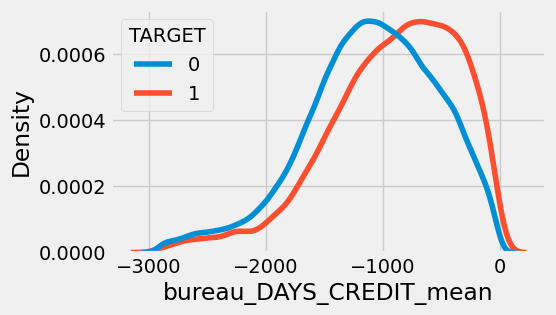

In [24]:
plt.figure(figsize=(5,3))
sns.kdeplot(
    data = bureau_numeric_agg_plot,
    x = 'bureau_DAYS_CREDIT_mean',
    hue = 'TARGET',
    common_norm=False
)

可以看到，分布还是有点区别，那些`DAYS_CREDIT_mean` 平均贷款天数更多的越容易违约

#### categorical columns
`bureau_categorical_agg`

对于分类变量， 我们可以统计次数和平均次数

In [25]:
bureau_categorical = pd.get_dummies(bureau.select_dtypes(include='str'))
bureau_categorical['SK_ID_CURR'] = bureau['SK_ID_CURR']
bureau_categorical

,CREDIT_ACTIVE_Active,CREDIT_ACTIVE_Bad debt,CREDIT_ACTIVE_Closed,CREDIT_ACTIVE_Sold,CREDIT_CURRENCY_currency 1,CREDIT_CURRENCY_currency 2,CREDIT_CURRENCY_currency 3,CREDIT_CURRENCY_currency 4,CREDIT_TYPE_Another type of loan,CREDIT_TYPE_Car loan,...,CREDIT_TYPE_Loan for business development,CREDIT_TYPE_Loan for purchase of shares (margin lending),CREDIT_TYPE_Loan for the purchase of equipment,CREDIT_TYPE_Loan for working capital replenishment,CREDIT_TYPE_Microloan,CREDIT_TYPE_Mobile operator loan,CREDIT_TYPE_Mortgage,CREDIT_TYPE_Real estate loan,CREDIT_TYPE_Unknown type of loan,SK_ID_CURR
0,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,215354
1,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,215354
2,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,215354
3,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,215354
4,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,215354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,259355
1716424,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,100044
1716425,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,100044
1716426,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,246829


In [26]:
bureau_categorical_agg = bureau_categorical.groupby(by='SK_ID_CURR').agg(
    ['sum', 'mean']
)
bureau_categorical_agg.head()

CREDIT_ACTIVE_Active           CREDIT_ACTIVE_Bad debt       \
                            sum      mean                    sum mean   
SK_ID_CURR                                                              
100001                        3  0.428571                      0  0.0   
100002                        2  0.250000                      0  0.0   
100003                        1  0.250000                      0  0.0   
100004                        0  0.000000                      0  0.0   
100005                        2  0.666667                      0  0.0   

           CREDIT_ACTIVE_Closed           CREDIT_ACTIVE_Sold       \
                            sum      mean                sum mean   
SK_ID_CURR                                                          
100001                        4  0.571429                  0  0.0   
100002                        6  0.750000                  0  0.0   
100003                        3  0.750000                  0  0.0   
100004                        2  1.000000                  0  0.0   
100005                        1  0.333333                  0  0.0   

           CREDIT_CURRENCY_currency 1       ... CREDIT_TYPE_Microloan       \
                                  sum mean  ...                   sum mean   
SK_ID_CURR                                  ...                              
100001                              7  1.0  ...                     0  0.0   
100002                              8  1.0  ...                     0  0.0   
100003                              4  1.0  ...                     0  0.0   
100004                              2  1.0  ...                     0  0.0   
100005                              3  1.0  ...                     0  0.0   

           CREDIT_TYPE_Mobile operator loan      CREDIT_TYPE_Mortgage       \
                                        sum mean                  sum mean   
SK_ID_CURR                                                                   
100001                                    0  0.0                    0  0.0   
100002                                    0  0.0                    0  0.0   
100003                                    0  0.0                    0  0.0   
100004                                    0  0.0                    0  0.0   
100005                                    0  0.0                    0  0.0   

           CREDIT_TYPE_Real estate loan      CREDIT_TYPE_Unknown type of loan  \
                                    sum mean                              sum   
SK_ID_CURR                                                                      
100001                                0  0.0                                0   
100002                                0  0.0                                0   
100003                                0  0.0                                0   
100004                                0  0.0                                0   
100005                                0  0.0                                0   

                 
           mean  
SK_ID_CURR       
100001      0.0  
100002      0.0  
100003      0.0  
100004      0.0  
100005      0.0  

[5 rows x 46 columns]

In [27]:
bureau_categorical_agg.columns[0]

('CREDIT_ACTIVE_Active', 'sum')

In [28]:
bureau_categorical_agg.columns = [ f'bureau_{col[0]}_{col[1]}' for col in bureau_categorical_agg.columns]
bureau_categorical_agg.head()

,bureau_CREDIT_ACTIVE_Active_sum,bureau_CREDIT_ACTIVE_Active_mean,bureau_CREDIT_ACTIVE_Bad debt_sum,bureau_CREDIT_ACTIVE_Bad debt_mean,bureau_CREDIT_ACTIVE_Closed_sum,bureau_CREDIT_ACTIVE_Closed_mean,bureau_CREDIT_ACTIVE_Sold_sum,bureau_CREDIT_ACTIVE_Sold_mean,bureau_CREDIT_CURRENCY_currency 1_sum,bureau_CREDIT_CURRENCY_currency 1_mean,...,bureau_CREDIT_TYPE_Microloan_sum,bureau_CREDIT_TYPE_Microloan_mean,bureau_CREDIT_TYPE_Mobile operator loan_sum,bureau_CREDIT_TYPE_Mobile operator loan_mean,bureau_CREDIT_TYPE_Mortgage_sum,bureau_CREDIT_TYPE_Mortgage_mean,bureau_CREDIT_TYPE_Real estate loan_sum,bureau_CREDIT_TYPE_Real estate loan_mean,bureau_CREDIT_TYPE_Unknown type of loan_sum,bureau_CREDIT_TYPE_Unknown type of loan_mean
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,3,0.428571,0,0.0,4,0.571429,0,0.0,7,1.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
100002,2,0.250000,0,0.0,6,0.750000,0,0.0,8,1.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
100003,1,0.250000,0,0.0,3,0.750000,0,0.0,4,1.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
100004,0,0.000000,0,0.0,2,1.000000,0,0.0,2,1.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
100005,2,0.666667,0,0.0,1,0.333333,0,0.0,3,1.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0


In [29]:
bureau_categorical_agg = bureau_categorical_agg.reset_index()
bureau_categorical_agg.head()

,SK_ID_CURR,bureau_CREDIT_ACTIVE_Active_sum,bureau_CREDIT_ACTIVE_Active_mean,bureau_CREDIT_ACTIVE_Bad debt_sum,bureau_CREDIT_ACTIVE_Bad debt_mean,bureau_CREDIT_ACTIVE_Closed_sum,bureau_CREDIT_ACTIVE_Closed_mean,bureau_CREDIT_ACTIVE_Sold_sum,bureau_CREDIT_ACTIVE_Sold_mean,bureau_CREDIT_CURRENCY_currency 1_sum,...,bureau_CREDIT_TYPE_Microloan_sum,bureau_CREDIT_TYPE_Microloan_mean,bureau_CREDIT_TYPE_Mobile operator loan_sum,bureau_CREDIT_TYPE_Mobile operator loan_mean,bureau_CREDIT_TYPE_Mortgage_sum,bureau_CREDIT_TYPE_Mortgage_mean,bureau_CREDIT_TYPE_Real estate loan_sum,bureau_CREDIT_TYPE_Real estate loan_mean,bureau_CREDIT_TYPE_Unknown type of loan_sum,bureau_CREDIT_TYPE_Unknown type of loan_mean
0,100001,3,0.428571,0,0.0,4,0.571429,0,0.0,7,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
1,100002,2,0.250000,0,0.0,6,0.750000,0,0.0,8,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
2,100003,1,0.250000,0,0.0,3,0.750000,0,0.0,4,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
3,100004,0,0.000000,0,0.0,2,1.000000,0,0.0,2,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
4,100005,2,0.666667,0,0.0,1,0.333333,0,0.0,3,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0


把上述特征合并起来

In [30]:
print(bureau_categorical_agg.shape, bureau_previous_loan_counts.shape, bureau_numeric_agg.shape)

(305811, 47) (305811, 2) (305811, 49)


In [31]:
dfs = [df.set_index('SK_ID_CURR') for df in [bureau_categorical_agg, bureau_previous_loan_counts, bureau_numeric_agg]]
bureau_agg = pd.concat(dfs, axis=1)
bureau_agg = bureau_agg.reset_index()
bureau_agg.head()

,SK_ID_CURR,bureau_CREDIT_ACTIVE_Active_sum,bureau_CREDIT_ACTIVE_Active_mean,bureau_CREDIT_ACTIVE_Bad debt_sum,bureau_CREDIT_ACTIVE_Bad debt_mean,bureau_CREDIT_ACTIVE_Closed_sum,bureau_CREDIT_ACTIVE_Closed_mean,bureau_CREDIT_ACTIVE_Sold_sum,bureau_CREDIT_ACTIVE_Sold_mean,bureau_CREDIT_CURRENCY_currency 1_sum,...,bureau_AMT_CREDIT_SUM_OVERDUE_max,bureau_AMT_CREDIT_SUM_OVERDUE_sum,bureau_DAYS_CREDIT_UPDATE_min,bureau_DAYS_CREDIT_UPDATE_mean,bureau_DAYS_CREDIT_UPDATE_max,bureau_DAYS_CREDIT_UPDATE_sum,bureau_AMT_ANNUITY_min,bureau_AMT_ANNUITY_mean,bureau_AMT_ANNUITY_max,bureau_AMT_ANNUITY_sum
0,100001,3,0.428571,0,0.0,4,0.571429,0,0.0,7,...,0.0,0.0,-155,-93.142857,-6,-652,0.0,3545.357143,10822.5,24817.5
1,100002,2,0.250000,0,0.0,6,0.750000,0,0.0,8,...,0.0,0.0,-1185,-499.875000,-7,-3999,0.0,0.000000,0.0,0.0
2,100003,1,0.250000,0,0.0,3,0.750000,0,0.0,4,...,0.0,0.0,-2131,-816.000000,-43,-3264,NaN,NaN,NaN,0.0
3,100004,0,0.000000,0,0.0,2,1.000000,0,0.0,2,...,0.0,0.0,-682,-532.000000,-382,-1064,NaN,NaN,NaN,0.0
4,100005,2,0.666667,0,0.0,1,0.333333,0,0.0,3,...,0.0,0.0,-121,-54.333333,-11,-163,0.0,1420.500000,4261.5,4261.5


In [32]:
bureau_agg.shape

(305811, 96)

In [33]:
bureau_agg.to_feather('checkpoints/02_bureau_agg.feather')

In [34]:
del bureau_categorical_agg, bureau_previous_loan_counts, bureau_numeric_agg,bureau_agg
gc.collect()

132

### bureau_balance
- 产生 `bureau_balance_by_client_agg`

In [35]:
train = pd.read_feather('checkpoints/01_train_app_base.feather')
test = pd.read_feather('checkpoints/01_test_app_base.feather')

In [36]:
bureau_balance = pd.read_csv('data/bureau_balance.csv')
bureau_balance.shape

(27299925, 3)

In [37]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [38]:
bureau_balance.dtypes

SK_ID_BUREAU      int64
MONTHS_BALANCE    int64
STATUS              str
dtype: object

In [39]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


因此对于`MONTHS_BALANCE` 可以聚合数字特征。`STATUS` 为分类统计。

这是很多相同的。我们可以为此写两个函数`agg_numeric` `agg_categorical`

In [40]:
def agg_numeric(df : pd.DataFrame, group_column, df_name = '', exclude_columns = []):
    """ 聚合数值特征: ['min', 'max', 'mean', 'sum'] 这是一般共有的
    group_column:
    df_name:
    exclude_columns: 需要排除一些id列. 一般不需要。
    """
    numeric_df = df.select_dtypes('number')
    numeric_df = numeric_df.drop(columns = exclude_columns)

    numeric_df[group_column] = df[group_column]
    numeric_df_agg = numeric_df.groupby(by = group_column).agg(
        ['min', 'max', 'mean', 'sum']
    )
    prefix = f'{df_name}_' if df_name != '' else ''
    numeric_df_agg.columns = [
        f"{prefix}{col[0]}_{col[1]}".upper()
        for col in numeric_df_agg.columns.values
    ]
    numeric_df_agg = numeric_df_agg.reset_index()
    return numeric_df_agg

In [41]:
def agg_categorical(df : pd.DataFrame, group_column, df_name=''):
    """ 聚合数值特征: ['mean', 'sum'] 这是一般共有的
    group_column:
    df_name:
    """
    categorical_df = pd.get_dummies(df.select_dtypes(include = ['str', 'object', 'category']))
    categorical_df[group_column] = df[group_column]
    categorical_df_agg = categorical_df.groupby(by = group_column).agg(
        ['mean', 'sum']
    )
    categorical_df_agg.columns =  [
        f"{df_name}_{col[0]}_{col[1]}" if col[1] != "" else col[0] 
        for col in categorical_df_agg.columns.values
    ]
    categorical_df_agg = categorical_df_agg.reset_index()
    return categorical_df_agg

In [42]:
bureau_balance_numeric_agg = agg_numeric(bureau_balance, 'SK_ID_BUREAU', 'bureau', exclude_columns=['SK_ID_BUREAU'])
bureau_balance_numeric_agg.head()

,SK_ID_BUREAU,BUREAU_MONTHS_BALANCE_MIN,BUREAU_MONTHS_BALANCE_MAX,BUREAU_MONTHS_BALANCE_MEAN,BUREAU_MONTHS_BALANCE_SUM
0,5001709,-96,0,-48.0,-4656
1,5001710,-82,0,-41.0,-3403
2,5001711,-3,0,-1.5,-6
3,5001712,-18,0,-9.0,-171
4,5001713,-21,0,-10.5,-231


In [43]:
bureau_balance_numeric_agg.shape

(817395, 5)

In [44]:
bureau_balance_categorical_agg = agg_categorical(bureau_balance, 'SK_ID_BUREAU', 'bureau')
bureau_balance_categorical_agg.head()

,SK_ID_BUREAU,bureau_STATUS_0_mean,bureau_STATUS_0_sum,bureau_STATUS_1_mean,bureau_STATUS_1_sum,bureau_STATUS_2_mean,bureau_STATUS_2_sum,bureau_STATUS_3_mean,bureau_STATUS_3_sum,bureau_STATUS_4_mean,bureau_STATUS_4_sum,bureau_STATUS_5_mean,bureau_STATUS_5_sum,bureau_STATUS_C_mean,bureau_STATUS_C_sum,bureau_STATUS_X_mean,bureau_STATUS_X_sum
0,5001709,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.886598,86,0.113402,11
1,5001710,0.060241,5,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.578313,48,0.361446,30
2,5001711,0.750000,3,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.000000,0,0.250000,1
3,5001712,0.526316,10,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.473684,9,0.000000,0
4,5001713,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.000000,0,1.000000,22


In [45]:
bureau_balance_categorical_agg.shape

(817395, 17)

In [46]:
bureau_balance_agg = pd.merge(bureau_balance_numeric_agg, bureau_balance_categorical_agg, on='SK_ID_BUREAU', how='left')
bureau_balance_agg.head()

,SK_ID_BUREAU,BUREAU_MONTHS_BALANCE_MIN,BUREAU_MONTHS_BALANCE_MAX,BUREAU_MONTHS_BALANCE_MEAN,BUREAU_MONTHS_BALANCE_SUM,bureau_STATUS_0_mean,bureau_STATUS_0_sum,bureau_STATUS_1_mean,bureau_STATUS_1_sum,bureau_STATUS_2_mean,...,bureau_STATUS_3_mean,bureau_STATUS_3_sum,bureau_STATUS_4_mean,bureau_STATUS_4_sum,bureau_STATUS_5_mean,bureau_STATUS_5_sum,bureau_STATUS_C_mean,bureau_STATUS_C_sum,bureau_STATUS_X_mean,bureau_STATUS_X_sum
0,5001709,-96,0,-48.0,-4656,0.000000,0,0.0,0,0.0,...,0.0,0,0.0,0,0.0,0,0.886598,86,0.113402,11
1,5001710,-82,0,-41.0,-3403,0.060241,5,0.0,0,0.0,...,0.0,0,0.0,0,0.0,0,0.578313,48,0.361446,30
2,5001711,-3,0,-1.5,-6,0.750000,3,0.0,0,0.0,...,0.0,0,0.0,0,0.0,0,0.000000,0,0.250000,1
3,5001712,-18,0,-9.0,-171,0.526316,10,0.0,0,0.0,...,0.0,0,0.0,0,0.0,0,0.473684,9,0.000000,0
4,5001713,-21,0,-10.5,-231,0.000000,0,0.0,0,0.0,...,0.0,0,0.0,0,0.0,0,0.000000,0,1.000000,22


进一步聚合到SK_ID_CURR

In [47]:
bureau[['SK_ID_CURR', 'SK_ID_BUREAU']]

,SK_ID_CURR,SK_ID_BUREAU
0,215354,5714462
1,215354,5714463
2,215354,5714464
3,215354,5714465
4,215354,5714466
...,...,...
1716423,259355,5057750
1716424,100044,5057754
1716425,100044,5057762
1716426,246829,5057770


In [48]:
bureau_balance_by_client = pd.merge(
    bureau_balance_agg,
    bureau[['SK_ID_CURR', 'SK_ID_BUREAU']], on='SK_ID_BUREAU', how='right'
    )

In [49]:
bureau_balance_by_client.head()

,SK_ID_BUREAU,BUREAU_MONTHS_BALANCE_MIN,BUREAU_MONTHS_BALANCE_MAX,BUREAU_MONTHS_BALANCE_MEAN,BUREAU_MONTHS_BALANCE_SUM,bureau_STATUS_0_mean,bureau_STATUS_0_sum,bureau_STATUS_1_mean,bureau_STATUS_1_sum,bureau_STATUS_2_mean,...,bureau_STATUS_3_sum,bureau_STATUS_4_mean,bureau_STATUS_4_sum,bureau_STATUS_5_mean,bureau_STATUS_5_sum,bureau_STATUS_C_mean,bureau_STATUS_C_sum,bureau_STATUS_X_mean,bureau_STATUS_X_sum,SK_ID_CURR
0,5714462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,215354
1,5714463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,215354
2,5714464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,215354
3,5714465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,215354
4,5714466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,215354


这里id-bureau 会有多个，因为每个用户之前有多个申请记录， 我们聚合一下

In [50]:
bureau_balance_by_client_agg = agg_numeric(bureau_balance_by_client, 'SK_ID_CURR', '', exclude_columns=['SK_ID_CURR', 'SK_ID_BUREAU'])

In [51]:
bureau_balance_by_client_agg.head()

,SK_ID_CURR,BUREAU_MONTHS_BALANCE_MIN_MIN,BUREAU_MONTHS_BALANCE_MIN_MAX,BUREAU_MONTHS_BALANCE_MIN_MEAN,BUREAU_MONTHS_BALANCE_MIN_SUM,BUREAU_MONTHS_BALANCE_MAX_MIN,BUREAU_MONTHS_BALANCE_MAX_MAX,BUREAU_MONTHS_BALANCE_MAX_MEAN,BUREAU_MONTHS_BALANCE_MAX_SUM,BUREAU_MONTHS_BALANCE_MEAN_MIN,...,BUREAU_STATUS_C_SUM_MEAN,BUREAU_STATUS_C_SUM_SUM,BUREAU_STATUS_X_MEAN_MIN,BUREAU_STATUS_X_MEAN_MAX,BUREAU_STATUS_X_MEAN_MEAN,BUREAU_STATUS_X_MEAN_SUM,BUREAU_STATUS_X_SUM_MIN,BUREAU_STATUS_X_SUM_MAX,BUREAU_STATUS_X_SUM_MEAN,BUREAU_STATUS_X_SUM_SUM
0,100001,-51.0,-1.0,-23.571429,-165.0,0.0,0.0,0.0,0.0,-25.5,...,15.714286,110.0,0.0,0.500000,0.214590,1.502129,0.0,9.0,4.285714,30.0
1,100002,-47.0,-3.0,-28.250000,-226.0,-32.0,0.0,-15.5,-124.0,-39.5,...,2.875000,23.0,0.0,0.500000,0.161932,1.295455,0.0,3.0,1.875000,15.0
2,100003,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.0
3,100004,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.0
4,100005,-12.0,-2.0,-6.000000,-18.0,0.0,0.0,0.0,0.0,-6.0,...,1.666667,5.0,0.0,0.333333,0.136752,0.410256,0.0,1.0,0.666667,2.0


由于一对多，所以行数增加的

In [52]:
bureau_balance_by_client_agg.to_feather('checkpoints/02_bureau_balance_agg.feather')

#### 特征选择

In [53]:
bureau_balance_agg = pd.read_feather('checkpoints/02_bureau_balance_agg.feather')
bureau_agg = pd.read_feather('checkpoints/02_bureau_agg.feather')

train = pd.read_feather('checkpoints/01_train_app_base.feather')
test = pd.read_feather('checkpoints/01_test_app_base.feather')
print(train.shape, test.shape)

train = pd.merge(train, bureau_agg, on='SK_ID_CURR', how='left')
train = pd.merge(train, bureau_balance_agg, on='SK_ID_CURR', how='left')
test = pd.merge(test, bureau_agg, on='SK_ID_CURR', how='left')
test = pd.merge(test, bureau_balance_agg, on='SK_ID_CURR', how='left')

print(train.shape, test.shape)

(307511, 243) (48744, 242)
(307511, 418) (48744, 417)


#### 缺失值

In [54]:
def missing_values_table(df):
    """ 统计缺失值
    """
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(columns= {0:'Missing Values', 1:'% of total values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns.sort_values(by='% of total values', ascending = False)
    mis_val_table_ren_columns = mis_val_table_ren_columns.loc[mis_val_table_ren_columns['% of total values'] != 0, :]

    return mis_val_table_ren_columns

In [55]:
missing_train = missing_values_table(train)
missing_train.head(10)

,Missing Values,% of total values
bureau_AMT_ANNUITY_max,227502,73.981744
bureau_AMT_ANNUITY_mean,227502,73.981744
bureau_AMT_ANNUITY_min,227502,73.981744
BUREAU_STATUS_3_SUM_MIN,215280,70.007252
BUREAU_STATUS_3_MEAN_MAX,215280,70.007252
BUREAU_STATUS_2_SUM_MIN,215280,70.007252
BUREAU_STATUS_2_MEAN_MIN,215280,70.007252
BUREAU_STATUS_2_MEAN_MEAN,215280,70.007252
BUREAU_STATUS_2_MEAN_MAX,215280,70.007252
BUREAU_STATUS_2_SUM_MEAN,215280,70.007252


对于一些缺失过多的字段可以考虑删除掉。比如去掉 超过90%的列

In [56]:
missing_90_columns = missing_train.index[missing_train['% of total values'] > 90]

In [57]:
missing_90_columns

Index([], dtype='str')

In [58]:
missing_values_table(test)

,Missing Values,% of total values
COMMONAREA_AVG,33495,68.716150
COMMONAREA_MODE,33495,68.716150
COMMONAREA_MEDI,33495,68.716150
NONLIVINGAPARTMENTS_MODE,33347,68.412523
NONLIVINGAPARTMENTS_MEDI,33347,68.412523
...,...,...
OBS_60_CNT_SOCIAL_CIRCLE,29,0.059495
DEF_60_CNT_SOCIAL_CIRCLE,29,0.059495
DEF_30_CNT_SOCIAL_CIRCLE,29,0.059495
AMT_ANNUITY,24,0.049237


#### 对齐train和test列

In [59]:
print(train.shape, test.shape)

(307511, 418) (48744, 417)


In [60]:
train_labels = train['TARGET']
train, test = train.align(test, join='inner', axis=1)
train['TARGET'] = train_labels

In [61]:
print(train.shape, test.shape)

(307511, 418) (48744, 417)


#### 相关矩阵

In [62]:
%%time
corrs = train.corr()

CPU times: total: 2min
Wall time: 2min 1s


In [63]:
corrs_sorted = corrs.sort_values(by='TARGET', ascending=False)

In [64]:
corrs_sorted['TARGET'].head(10)

TARGET                              1.000000
bureau_DAYS_CREDIT_mean             0.089729
BUREAU_MONTHS_BALANCE_MIN_MEAN      0.089038
DAYS_BIRTH                          0.078239
bureau_CREDIT_ACTIVE_Active_mean    0.077356
BUREAU_MONTHS_BALANCE_MEAN_MEAN     0.076424
bureau_DAYS_CREDIT_min              0.075248
BUREAU_MONTHS_BALANCE_MIN_MIN       0.073225
BUREAU_MONTHS_BALANCE_SUM_MEAN      0.072606
bureau_DAYS_CREDIT_UPDATE_mean      0.068927
Name: TARGET, dtype: float64

In [65]:
corrs_sorted['TARGET'].tail(10)

NAME_INCOME_TYPE_Pensioner             -0.046209
CODE_GENDER_F                          -0.054704
BUREAU_STATUS_C_MEAN_MEAN              -0.055936
NAME_EDUCATION_TYPE_Higher education   -0.056593
BUREAU_STATUS_C_SUM_MAX                -0.061083
BUREAU_STATUS_C_SUM_MEAN               -0.062954
bureau_CREDIT_ACTIVE_Closed_mean       -0.079369
EXT_SOURCE_1                           -0.155317
EXT_SOURCE_2                           -0.160472
EXT_SOURCE_3                           -0.178919
Name: TARGET, dtype: float64

可以看到，我们的一些新特征确实有更好的相关性

<Axes: xlabel='bureau_CREDIT_ACTIVE_Active_mean', ylabel='Density'>

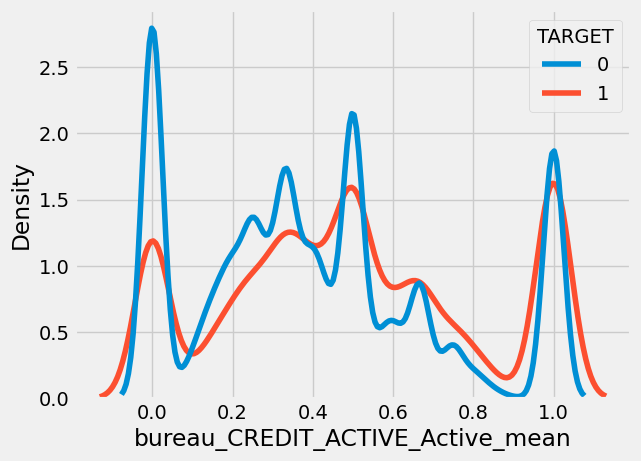

In [66]:
sns.kdeplot(
    data = train,
    x = 'bureau_CREDIT_ACTIVE_Active_mean',
    hue = 'TARGET',
    common_norm = False
)

好吧，目前看来没啥用

此外我们可以剔除一些高度相关变量

In [67]:
corrs.head()

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,BUREAU_STATUS_C_SUM_SUM,BUREAU_STATUS_X_MEAN_MIN,BUREAU_STATUS_X_MEAN_MAX,BUREAU_STATUS_X_MEAN_MEAN,BUREAU_STATUS_X_MEAN_SUM,BUREAU_STATUS_X_SUM_MIN,BUREAU_STATUS_X_SUM_MAX,BUREAU_STATUS_X_SUM_MEAN,BUREAU_STATUS_X_SUM_SUM,TARGET
SK_ID_CURR,1.000000,-0.001129,-0.001820,-0.000343,-0.000433,-0.000232,0.000849,-0.001500,0.001366,-0.000973,...,0.000252,-0.003102,0.003164,0.000689,0.001937,-0.003786,-0.002939,-0.003459,-0.000683,-0.002108
CNT_CHILDREN,-0.001129,1.000000,0.012882,0.002145,0.021374,-0.001827,-0.025573,0.330938,-0.239818,0.183395,...,-0.005527,-0.001161,0.005020,0.002323,-0.001398,-0.003052,-0.003205,-0.004988,-0.003957,0.019187
AMT_INCOME_TOTAL,-0.001820,0.012882,1.000000,0.156870,0.191657,0.159610,0.074796,0.027261,-0.064223,0.027805,...,0.024610,-0.031615,0.074149,0.020127,0.026904,-0.021876,0.060925,0.022379,0.024900,-0.003982
AMT_CREDIT,-0.000343,0.002145,0.156870,1.000000,0.770138,0.986968,0.099738,-0.055436,-0.066838,0.009621,...,0.023609,0.003360,0.023895,0.019604,0.015181,0.014507,0.038554,0.036641,0.024139,-0.030369
AMT_ANNUITY,-0.000433,0.021374,0.191657,0.770138,1.000000,0.775109,0.118429,0.009445,-0.104332,0.038514,...,0.101982,-0.006178,0.019453,0.007627,0.076965,0.009223,0.036626,0.030085,0.077655,-0.012817


In [68]:
corr_abs = corrs.abs()

In [69]:
threshold = 0.8
high_corr = {}
for col in corr_abs:
    high_corr[col] = list(corr_abs.index[(corr_abs[col] > threshold) & (corr_abs[col] != 1)])
high_corr

{'SK_ID_CURR': [],
 'CNT_CHILDREN': ['CNT_FAM_MEMBERS'],
 'AMT_INCOME_TOTAL': [],
 'AMT_CREDIT': ['AMT_GOODS_PRICE'],
 'AMT_ANNUITY': [],
 'AMT_GOODS_PRICE': ['AMT_CREDIT'],
 'REGION_POPULATION_RELATIVE': [],
 'DAYS_BIRTH': [],
 'DAYS_EMPLOYED': ['FLAG_EMP_PHONE',
  'NAME_INCOME_TYPE_Pensioner',
  'ORGANIZATION_TYPE_XNA'],
 'DAYS_REGISTRATION': [],
 'DAYS_ID_PUBLISH': [],
 'OWN_CAR_AGE': [],
 'FLAG_MOBIL': [],
 'FLAG_EMP_PHONE': ['DAYS_EMPLOYED',
  'NAME_INCOME_TYPE_Pensioner',
  'ORGANIZATION_TYPE_XNA'],
 'FLAG_WORK_PHONE': [],
 'FLAG_CONT_MOBILE': [],
 'FLAG_PHONE': [],
 'FLAG_EMAIL': [],
 'CNT_FAM_MEMBERS': ['CNT_CHILDREN'],
 'REGION_RATING_CLIENT': ['REGION_RATING_CLIENT_W_CITY'],
 'REGION_RATING_CLIENT_W_CITY': ['REGION_RATING_CLIENT'],
 'HOUR_APPR_PROCESS_START': [],
 'REG_REGION_NOT_LIVE_REGION': [],
 'REG_REGION_NOT_WORK_REGION': ['LIVE_REGION_NOT_WORK_REGION'],
 'LIVE_REGION_NOT_WORK_REGION': ['REG_REGION_NOT_WORK_REGION'],
 'REG_CITY_NOT_LIVE_CITY': [],
 'REG_CITY_NOT_WORK_CI

对于高度相关的特征对.
- 如果

In [70]:
upper = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
    )   
upper

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,BUREAU_STATUS_C_SUM_SUM,BUREAU_STATUS_X_MEAN_MIN,BUREAU_STATUS_X_MEAN_MAX,BUREAU_STATUS_X_MEAN_MEAN,BUREAU_STATUS_X_MEAN_SUM,BUREAU_STATUS_X_SUM_MIN,BUREAU_STATUS_X_SUM_MAX,BUREAU_STATUS_X_SUM_MEAN,BUREAU_STATUS_X_SUM_SUM,TARGET
SK_ID_CURR,NaN,0.001129,0.001820,0.000343,0.000433,0.000232,0.000849,0.001500,0.001366,0.000973,...,0.000252,0.003102,0.003164,0.000689,0.001937,0.003786,0.002939,0.003459,0.000683,0.002108
CNT_CHILDREN,NaN,NaN,0.012882,0.002145,0.021374,0.001827,0.025573,0.330938,0.239818,0.183395,...,0.005527,0.001161,0.005020,0.002323,0.001398,0.003052,0.003205,0.004988,0.003957,0.019187
AMT_INCOME_TOTAL,NaN,NaN,NaN,0.156870,0.191657,0.159610,0.074796,0.027261,0.064223,0.027805,...,0.024610,0.031615,0.074149,0.020127,0.026904,0.021876,0.060925,0.022379,0.024900,0.003982
AMT_CREDIT,NaN,NaN,NaN,NaN,0.770138,0.986968,0.099738,0.055436,0.066838,0.009621,...,0.023609,0.003360,0.023895,0.019604,0.015181,0.014507,0.038554,0.036641,0.024139,0.030369
AMT_ANNUITY,NaN,NaN,NaN,NaN,NaN,0.775109,0.118429,0.009445,0.104332,0.038514,...,0.101982,0.006178,0.019453,0.007627,0.076965,0.009223,0.036626,0.030085,0.077655,0.012817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BUREAU_STATUS_X_SUM_MIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.238225,0.655103,0.137826,0.014557
BUREAU_STATUS_X_SUM_MAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.784659,0.806159,0.030919
BUREAU_STATUS_X_SUM_MEAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.691279,0.033292
BUREAU_STATUS_X_SUM_SUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008445


In [71]:
high_corr_pairs = upper.unstack().reset_index()
high_corr_pairs.columns = ['feature_1', 'feature_2', 'corr']
high_corr_pairs = high_corr_pairs[high_corr_pairs['corr'] > threshold]
high_corr_pairs

,feature_1,feature_2,corr
2093,AMT_GOODS_PRICE,AMT_CREDIT,0.986968
5442,FLAG_EMP_PHONE,DAYS_EMPLOYED,0.999755
7525,CNT_FAM_MEMBERS,CNT_CHILDREN,0.879161
8379,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.950842
10055,LIVE_REGION_NOT_WORK_REGION,REG_REGION_NOT_WORK_REGION,0.860627
...,...,...,...
170884,BUREAU_STATUS_C_SUM_SUM,BUREAU_MONTHS_BALANCE_MIN_SUM,0.847094
170896,BUREAU_STATUS_C_SUM_SUM,BUREAU_MONTHS_BALANCE_SUM_SUM,0.892464
170948,BUREAU_STATUS_C_SUM_SUM,BUREAU_STATUS_C_MEAN_SUM,0.911103
174300,BUREAU_STATUS_X_SUM_SUM,BUREAU_STATUS_X_MEAN_SUM,0.857403


In [72]:
to_drop = set()
missing_counts = train.isnull().sum()
for index, row in high_corr_pairs.iterrows():
    f1, f2 = row['feature_1'], row['feature_2']
    if f1 in to_drop or f2 in to_drop: # 有一个已经在drop了
        continue
    if missing_counts[f1] > missing_counts[f2]:
        to_drop.add(f1)
    else:
        to_drop.add(f2)
to_drop = list(to_drop)
to_drop

['BUREAU_MONTHS_BALANCE_MIN_SUM',
 'CODE_GENDER_F',
 'BUREAU_STATUS_2_MEAN_SUM',
 'BUREAU_MONTHS_BALANCE_MAX_SUM',
 'bureau_CREDIT_ACTIVE_Closed_sum',
 'REG_CITY_NOT_WORK_CITY',
 'BUREAU_STATUS_C_MEAN_MEAN',
 'bureau_CREDIT_CURRENCY_currency 1_mean',
 'APARTMENTS_AVG',
 'LIVINGAPARTMENTS_MEDI',
 'bureau_CREDIT_TYPE_Consumer credit_mean',
 'FLAG_OWN_REALTY_N',
 'APARTMENTS_MODE',
 'BUREAU_STATUS_C_MEAN_SUM',
 'bureau_CREDIT_TYPE_Loan for purchase of shares (margin lending)_sum',
 'ELEVATORS_MEDI',
 'LIVINGAREA_MODE',
 'ENTRANCES_AVG',
 'bureau_CREDIT_TYPE_Cash loan (non-earmarked)_sum',
 'REGION_RATING_CLIENT',
 'bureau_AMT_ANNUITY_max',
 'FLOORSMIN_MODE',
 'BUREAU_STATUS_5_MEAN_SUM',
 'YEARS_BUILD_AVG',
 'LIVINGAREA_AVG',
 'bureau_AMT_CREDIT_MAX_OVERDUE_mean',
 'FLAG_OWN_CAR_N',
 'BUREAU_STATUS_4_MEAN_MEAN',
 'bureau_previous_loan_counts',
 'BUREAU_STATUS_5_MEAN_MEAN',
 'BASEMENTAREA_AVG',
 'APARTMENTS_MEDI',
 'ELEVATORS_MODE',
 'AMT_GOODS_PRICE',
 'YEARS_BEGINEXPLUATATION_AVG',
 'BURE

从训练集和测试集移除这些列，

In [73]:
len(to_drop)

112

In [74]:
train.columns

Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'BUREAU_STATUS_C_SUM_SUM', 'BUREAU_STATUS_X_MEAN_MIN',
       'BUREAU_STATUS_X_MEAN_MAX', 'BUREAU_STATUS_X_MEAN_MEAN',
       'BUREAU_STATUS_X_MEAN_SUM', 'BUREAU_STATUS_X_SUM_MIN',
       'BUREAU_STATUS_X_SUM_MAX', 'BUREAU_STATUS_X_SUM_MEAN',
       'BUREAU_STATUS_X_SUM_SUM', 'TARGET'],
      dtype='str', length=418)

In [75]:
train_corrs_removed = train.drop(columns=to_drop)
test_corrs_removed = test.drop(columns=to_drop)

In [76]:
train_corrs_removed.to_feather('checkpoints/04_train_app_bureau_balance_bureau_cleaned.feather')
test_corrs_removed.to_feather('checkpoints/04_test_app_bureau_balance_bureau_cleaned.feather')

In [77]:
del corrs, corr_abs, train_corrs_removed, test_corrs_removed
gc.collect()

0

### modeling

#### 导入
- 每个model运行前，建议重新导入一次

In [78]:
train = pd.read_feather('checkpoints/04_train_app_bureau_balance_bureau_cleaned.feather')
test = pd.read_feather('checkpoints/04_test_app_bureau_balance_bureau_cleaned.feather')

train_labels = train['TARGET']
train_ids = train['SK_ID_CURR']
test_ids = test['SK_ID_CURR']
train_features = train.drop(columns=['TARGET', 'SK_ID_CURR'])
test_features = test.drop(columns=['SK_ID_CURR'])

In [79]:
print(train.shape, test.shape)

(307511, 306) (48744, 305)


#### HistGradientBoostingClassifier

In [80]:
from sklearn.ensemble import HistGradientBoostingClassifier

HistGradientBoostingClassifier 
- 不需要处理缺失值
- 树模型对量级不敏感，不需要scaler

In [81]:
%%time
hist_gradient_boost_model= HistGradientBoostingClassifier(
    max_iter = 100, # 树个数
    learning_rate = 0.1,
    max_depth = 5,
)
hist_gradient_boost_model.fit(train_features, train_labels)

CPU times: total: 2min 15s
Wall time: 17.6 s


,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,5
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [82]:
from sklearn.metrics import roc_auc_score
train_prob = hist_gradient_boost_model.predict_proba(train_features)
train_prob

array([[0.57789429, 0.42210571],
       [0.96788937, 0.03211063],
       [0.95496642, 0.04503358],
       ...,
       [0.91929918, 0.08070082],
       [0.92218583, 0.07781417],
       [0.9186571 , 0.0813429 ]], shape=(307511, 2))

In [83]:
from sklearn.metrics import  roc_curve
fpr, tpr, thresholds = roc_curve(train_labels, train_prob[:, 1])
auc = roc_auc_score(train_labels, train_prob[:, 1])

Text(0.5, 1.0, 'hist gb Roc curve, auc=0.789')

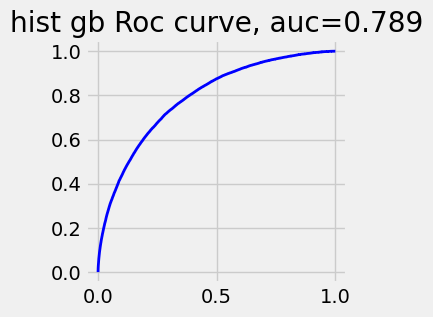

In [84]:
plt.figure(figsize=(3,3))
plt.plot(fpr, tpr, color='blue', lw=2)
plt.title(f'hist gb Roc curve, auc={auc:.3f}')

In [85]:
hist_gradient_boost_model_pred = hist_gradient_boost_model.predict_proba(test_features)

In [86]:
submit = pd.DataFrame({
    'SK_ID_CURR': test_ids
})
submit['TARGET'] = hist_gradient_boost_model_pred[:, 1]

submit.to_csv('hist_gradient_boost_model_with_bureau.csv', index = False)
submit.head()

,SK_ID_CURR,TARGET
0,100001,0.041575
1,100005,0.161436
2,100013,0.020080
3,100028,0.029833
4,100038,0.178684


In [87]:
submit.shape

(48744, 2)

得分73

#### lightgbm
- 需要清理列名

In [88]:
import re
# 1. 定义清理函数
def clean_names(df):
    # 替换所有非字母、数字的字符为下划线
    # 这里的正则 [^A-Za-z0-9_] 会匹配空格、斜杠、括号等所有特殊字符
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]
    # 顺便处理一下可能出现的重复下划线，比如 __
    df.columns = [re.sub(r'_+', '_', col).strip('_') for col in df.columns]
    return df

In [89]:
train_features = clean_names(train_features)
test_features = clean_names(test_features)

In [90]:
%%time
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(
    n_estimators=100,      # 对应 max_iter，树的个数
    learning_rate=0.1,     # 学习率
    max_depth=3,           # 树的最大深度
    random_state=42,       # 保证结果可复现
    n_jobs=-1              # 使用所有 CPU 核心加速
)
lgbm_model.fit(train_features, train_labels)

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.109867 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19607
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 298
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,3
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [91]:
lgbm_model_pred = lgbm_model.predict_proba(test_features)[:, 1]

In [92]:
submit = pd.DataFrame(
    {
        'SK_ID_CURR': test_ids
    }
)
submit['TARGET'] = lgbm_model_pred

submit.to_csv('lgbm_model_pred_with_bureau.csv', index = False)

得分 73

In [93]:
features_importance = pd.DataFrame(
    {
        'importance': lgbm_model.feature_importances_,
        'feature': lgbm_model.feature_name_
    }
)

In [ ]:
features_importance_plot = features_importance.sort_values(by='importance', ascending=False).head(20)
features_importance_plot.head()

,importance,feature
20,72,EXT_SOURCE_1
21,71,EXT_SOURCE_2
22,67,EXT_SOURCE_3
2,40,AMT_CREDIT
5,35,DAYS_BIRTH
228,21,bureau_DAYS_CREDIT_max
64,20,CODE_GENDER_M
244,18,bureau_AMT_CREDIT_SUM_DEBT_mean
3,18,AMT_ANNUITY
8,16,OWN_CAR_AGE


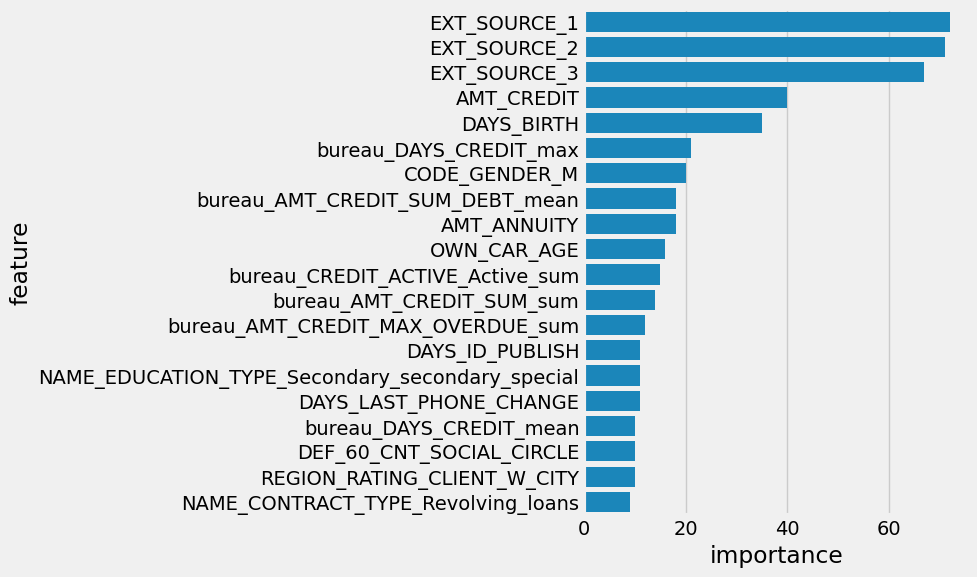

In [95]:
plt.figure(figsize=(10,6))
sns.barplot(
    data = features_importance_plot,
    x= 'importance',
    y = 'feature'
)
plt.tight_layout()

还是有点提升的，我们看到有一些新的重要特征

## 第二部分
- 按照第一部分步骤，做一些最基本的处理。使用`previous_application 、 POS_CASH_balance 、 installments_payments 和 credit_card_balance`文件

In [96]:
def get_missing_columns(df, rate=90):
    """只计算需要删除的列名"""
    missing_stats = df.isnull().sum() / len(df) * 100
    to_drop = missing_stats[missing_stats > rate].index.tolist()
    return to_drop

In [97]:
def get_high_corr_columns(df, threshold=0.9):
    """
    高效获取高相关特征，优先保留缺失值较少的特征
    """
    # 1. 计算相关性矩阵
    corr_matrix = df.corr().abs()
    
    # 2. 提取上三角（不含对角线）
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # 3. 找出所有超过阈值的列名
    # 这里的 to_drop 是我们要剔除的特征候选名单
    to_drop = set()
    
    # 4. 获取缺失值统计
    missing_counts = df.isnull().sum()
    
    # 5. 遍历每一列，检查是否存在高相关
    for column in upper.columns:
        # 找到与当前列 column 相关性大于阈值的所有特征
        high_corr_features = upper[column][upper[column] > threshold].index.tolist()
        
        for feature in high_corr_features:
            # 比较 column 和 feature 的缺失值情况
            # 谁缺失多删谁
            if missing_counts[column] > missing_counts[feature]:
                to_drop.add(column)
                break # column 既然要被删了，就不用再看它与其他特征的关系了
            else:
                to_drop.add(feature)
                
    return list(to_drop)


In [98]:
def feature_select(train, test):
    """ 移除 高缺失值列和高相关特征
    """ 
    train = train.copy()
    test = test.copy()

    train_labels = train['TARGET']
    train_ids = train['SK_ID_CURR']
    test_ids = test['SK_ID_CURR']

    # 这两列不参与
    train = train.drop(columns=['TARGET', 'SK_ID_CURR'])
    test = test.drop(columns=['SK_ID_CURR'])

    train = train.drop(columns=get_missing_columns(train))
    test = test.drop(columns=get_missing_columns(test))
    print('remove high missing cols. ', train.shape, test.shape)

    train, test = train.align(test, join='inner', axis=1)
    print('align train and test.', train.shape, test.shape)
    
    train_sample = train.sample(n=int(len(train) * 0.3))
    to_drop_columns = get_high_corr_columns(train_sample)
    train = train.drop(columns=to_drop_columns)
    test = test.drop(columns=to_drop_columns)
    
    train['TARGET'] = train_labels
    train['SK_ID_CURR'] = train_ids
    test['SK_ID_CURR'] = test_ids

    print('remove high corr cols.', train.shape, test.shape)

    return train, test

In [99]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import  roc_curve

def plot_roc(targets, prob, name):
    fpr, tpr, thresholds = roc_curve(targets, prob)
    auc = roc_auc_score(targets, prob)
    plt.figure(figsize=(3,3))
    plt.plot(fpr, tpr, color='blue', lw=2)
    plt.title(f'{name} Roc curve, auc={auc:.3f}')

### 引入previous_application表
- previous_agg_by_client

In [100]:
previous = pd.read_csv('data/previous_application.csv')


In [101]:
previous.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
previous.shape

(1670214, 37)

In [103]:
previous.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE',
       'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE',
       'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE',
       'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION',
       'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
       'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL'],
      dtype='str')

In [104]:
previous.dtypes

SK_ID_PREV                       int64
SK_ID_CURR                       int64
NAME_CONTRACT_TYPE                 str
AMT_ANNUITY                    float64
AMT_APPLICATION                float64
AMT_CREDIT                     float64
AMT_DOWN_PAYMENT               float64
AMT_GOODS_PRICE                float64
WEEKDAY_APPR_PROCESS_START         str
HOUR_APPR_PROCESS_START          int64
FLAG_LAST_APPL_PER_CONTRACT        str
NFLAG_LAST_APPL_IN_DAY           int64
RATE_DOWN_PAYMENT              float64
RATE_INTEREST_PRIMARY          float64
RATE_INTEREST_PRIVILEGED       float64
NAME_CASH_LOAN_PURPOSE             str
NAME_CONTRACT_STATUS               str
DAYS_DECISION                    int64
NAME_PAYMENT_TYPE                  str
CODE_REJECT_REASON                 str
NAME_TYPE_SUITE                    str
NAME_CLIENT_TYPE                   str
NAME_GOODS_CATEGORY                str
NAME_PORTFOLIO                     str
NAME_PRODUCT_TYPE                  str
CHANNEL_TYPE             

In [105]:
previous_categorical_agg = agg_categorical(previous, ['SK_ID_PREV', 'SK_ID_CURR'], 'previous')

In [106]:
previous_categorical_agg.head()

,SK_ID_PREV,SK_ID_CURR,previous_NAME_CONTRACT_TYPE_Cash loans_mean,previous_NAME_CONTRACT_TYPE_Cash loans_sum,previous_NAME_CONTRACT_TYPE_Consumer loans_mean,previous_NAME_CONTRACT_TYPE_Consumer loans_sum,previous_NAME_CONTRACT_TYPE_Revolving loans_mean,previous_NAME_CONTRACT_TYPE_Revolving loans_sum,previous_NAME_CONTRACT_TYPE_XNA_mean,previous_NAME_CONTRACT_TYPE_XNA_sum,...,previous_PRODUCT_COMBINATION_POS industry without interest_mean,previous_PRODUCT_COMBINATION_POS industry without interest_sum,previous_PRODUCT_COMBINATION_POS mobile with interest_mean,previous_PRODUCT_COMBINATION_POS mobile with interest_sum,previous_PRODUCT_COMBINATION_POS mobile without interest_mean,previous_PRODUCT_COMBINATION_POS mobile without interest_sum,previous_PRODUCT_COMBINATION_POS other with interest_mean,previous_PRODUCT_COMBINATION_POS other with interest_sum,previous_PRODUCT_COMBINATION_POS others without interest_mean,previous_PRODUCT_COMBINATION_POS others without interest_sum
0,1000001,158271,0.0,0,1.0,1,0.0,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
1,1000002,101962,0.0,0,1.0,1,0.0,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
2,1000003,252457,0.0,0,1.0,1,0.0,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
3,1000004,260094,0.0,0,1.0,1,0.0,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
4,1000005,176456,0.0,0,1.0,1,0.0,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0


In [107]:
previous_numeric_agg = agg_numeric(previous,['SK_ID_PREV', 'SK_ID_CURR'], 'previous')

In [108]:
previous_numeric_agg.head()

,SK_ID_PREV,SK_ID_CURR,PREVIOUS_AMT_ANNUITY_MIN,PREVIOUS_AMT_ANNUITY_MAX,PREVIOUS_AMT_ANNUITY_MEAN,PREVIOUS_AMT_ANNUITY_SUM,PREVIOUS_AMT_APPLICATION_MIN,PREVIOUS_AMT_APPLICATION_MAX,PREVIOUS_AMT_APPLICATION_MEAN,PREVIOUS_AMT_APPLICATION_SUM,...,PREVIOUS_DAYS_LAST_DUE_MEAN,PREVIOUS_DAYS_LAST_DUE_SUM,PREVIOUS_DAYS_TERMINATION_MIN,PREVIOUS_DAYS_TERMINATION_MAX,PREVIOUS_DAYS_TERMINATION_MEAN,PREVIOUS_DAYS_TERMINATION_SUM,PREVIOUS_NFLAG_INSURED_ON_APPROVAL_MIN,PREVIOUS_NFLAG_INSURED_ON_APPROVAL_MAX,PREVIOUS_NFLAG_INSURED_ON_APPROVAL_MEAN,PREVIOUS_NFLAG_INSURED_ON_APPROVAL_SUM
0,1000001,158271,6404.310,6404.310,6404.310,6404.310,58905.000,58905.000,58905.000,58905.000,...,-238.0,-238.0,-233.0,-233.0,-233.0,-233.0,0.0,0.0,0.0,0.0
1,1000002,101962,6264.000,6264.000,6264.000,6264.000,39145.500,39145.500,39145.500,39145.500,...,-1510.0,-1510.0,-1501.0,-1501.0,-1501.0,-1501.0,0.0,0.0,0.0,0.0
2,1000003,252457,4951.350,4951.350,4951.350,4951.350,47056.275,47056.275,47056.275,47056.275,...,365243.0,365243.0,365243.0,365243.0,365243.0,365243.0,1.0,1.0,1.0,1.0
3,1000004,260094,3391.110,3391.110,3391.110,3391.110,35144.370,35144.370,35144.370,35144.370,...,-682.0,-682.0,-672.0,-672.0,-672.0,-672.0,0.0,0.0,0.0,0.0
4,1000005,176456,14713.605,14713.605,14713.605,14713.605,123486.075,123486.075,123486.075,123486.075,...,-1418.0,-1418.0,-1415.0,-1415.0,-1415.0,-1415.0,0.0,0.0,0.0,0.0


In [109]:
previous_agg = pd.merge(previous_numeric_agg, previous_categorical_agg, on=['SK_ID_PREV', 'SK_ID_CURR'], how='left')
previous_agg.head()

,SK_ID_PREV,SK_ID_CURR,PREVIOUS_AMT_ANNUITY_MIN,PREVIOUS_AMT_ANNUITY_MAX,PREVIOUS_AMT_ANNUITY_MEAN,PREVIOUS_AMT_ANNUITY_SUM,PREVIOUS_AMT_APPLICATION_MIN,PREVIOUS_AMT_APPLICATION_MAX,PREVIOUS_AMT_APPLICATION_MEAN,PREVIOUS_AMT_APPLICATION_SUM,...,previous_PRODUCT_COMBINATION_POS industry without interest_mean,previous_PRODUCT_COMBINATION_POS industry without interest_sum,previous_PRODUCT_COMBINATION_POS mobile with interest_mean,previous_PRODUCT_COMBINATION_POS mobile with interest_sum,previous_PRODUCT_COMBINATION_POS mobile without interest_mean,previous_PRODUCT_COMBINATION_POS mobile without interest_sum,previous_PRODUCT_COMBINATION_POS other with interest_mean,previous_PRODUCT_COMBINATION_POS other with interest_sum,previous_PRODUCT_COMBINATION_POS others without interest_mean,previous_PRODUCT_COMBINATION_POS others without interest_sum
0,1000001,158271,6404.310,6404.310,6404.310,6404.310,58905.000,58905.000,58905.000,58905.000,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
1,1000002,101962,6264.000,6264.000,6264.000,6264.000,39145.500,39145.500,39145.500,39145.500,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
2,1000003,252457,4951.350,4951.350,4951.350,4951.350,47056.275,47056.275,47056.275,47056.275,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
3,1000004,260094,3391.110,3391.110,3391.110,3391.110,35144.370,35144.370,35144.370,35144.370,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
4,1000005,176456,14713.605,14713.605,14713.605,14713.605,123486.075,123486.075,123486.075,123486.075,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0


按照client聚合

In [110]:
previous_agg_by_client = agg_numeric(previous_agg, 'SK_ID_CURR', exclude_columns=['SK_ID_PREV'])

In [111]:
previous_agg_by_client.columns

Index(['SK_ID_CURR', 'PREVIOUS_AMT_ANNUITY_MIN_MIN',
       'PREVIOUS_AMT_ANNUITY_MIN_MAX', 'PREVIOUS_AMT_ANNUITY_MIN_MEAN',
       'PREVIOUS_AMT_ANNUITY_MIN_SUM', 'PREVIOUS_AMT_ANNUITY_MAX_MIN',
       'PREVIOUS_AMT_ANNUITY_MAX_MAX', 'PREVIOUS_AMT_ANNUITY_MAX_MEAN',
       'PREVIOUS_AMT_ANNUITY_MAX_SUM', 'PREVIOUS_AMT_ANNUITY_MEAN_MIN',
       ...
       'PREVIOUS_PRODUCT_COMBINATION_POS OTHER WITH INTEREST_SUM_MEAN',
       'PREVIOUS_PRODUCT_COMBINATION_POS OTHER WITH INTEREST_SUM_SUM',
       'PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_MIN',
       'PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_MAX',
       'PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_MEAN',
       'PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_SUM',
       'PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_SUM_MIN',
       'PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_SUM_MAX',
       'PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WIT

In [112]:
previous_agg_by_client.head()

,SK_ID_CURR,PREVIOUS_AMT_ANNUITY_MIN_MIN,PREVIOUS_AMT_ANNUITY_MIN_MAX,PREVIOUS_AMT_ANNUITY_MIN_MEAN,PREVIOUS_AMT_ANNUITY_MIN_SUM,PREVIOUS_AMT_ANNUITY_MAX_MIN,PREVIOUS_AMT_ANNUITY_MAX_MAX,PREVIOUS_AMT_ANNUITY_MAX_MEAN,PREVIOUS_AMT_ANNUITY_MAX_SUM,PREVIOUS_AMT_ANNUITY_MEAN_MIN,...,PREVIOUS_PRODUCT_COMBINATION_POS OTHER WITH INTEREST_SUM_MEAN,PREVIOUS_PRODUCT_COMBINATION_POS OTHER WITH INTEREST_SUM_SUM,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_MIN,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_MAX,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_MEAN,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_SUM,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_SUM_MIN,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_SUM_MAX,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_SUM_MEAN,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_SUM_SUM
0,100001,3951.000,3951.000,3951.000,3951.000,3951.000,3951.000,3951.000,3951.000,3951.000,...,0.0,0,0.0,0.0,0.0,0.0,0,0,0.0,0
1,100002,9251.775,9251.775,9251.775,9251.775,9251.775,9251.775,9251.775,9251.775,9251.775,...,1.0,1,0.0,0.0,0.0,0.0,0,0,0.0,0
2,100003,6737.310,98356.995,56553.990,169661.970,6737.310,98356.995,56553.990,169661.970,6737.310,...,0.0,0,0.0,0.0,0.0,0.0,0,0,0.0,0
3,100004,5357.250,5357.250,5357.250,5357.250,5357.250,5357.250,5357.250,5357.250,5357.250,...,0.0,0,0.0,0.0,0.0,0.0,0,0,0.0,0
4,100005,4813.200,4813.200,4813.200,4813.200,4813.200,4813.200,4813.200,4813.200,4813.200,...,0.0,0,0.0,0.0,0.0,0.0,0,0,0.0,0


In [113]:
sk_id_prev_cnts = previous_agg.groupby(by='SK_ID_CURR')['SK_ID_PREV'].count().reset_index().rename(columns = {'SK_ID_PREV' : 'prev_applications_counts'})

In [114]:
sk_id_prev_cnts

,SK_ID_CURR,prev_applications_counts
0,100001,1
1,100002,1
2,100003,3
3,100004,1
4,100005,2
...,...,...
338852,456251,1
338853,456252,1
338854,456253,2
338855,456254,2


In [115]:
previous_agg_by_client = pd.merge(
    previous_agg_by_client,
    sk_id_prev_cnts,
    on = 'SK_ID_CURR',
    how = 'left'
)

In [116]:
previous_agg_by_client

,SK_ID_CURR,PREVIOUS_AMT_ANNUITY_MIN_MIN,PREVIOUS_AMT_ANNUITY_MIN_MAX,PREVIOUS_AMT_ANNUITY_MIN_MEAN,PREVIOUS_AMT_ANNUITY_MIN_SUM,PREVIOUS_AMT_ANNUITY_MAX_MIN,PREVIOUS_AMT_ANNUITY_MAX_MAX,PREVIOUS_AMT_ANNUITY_MAX_MEAN,PREVIOUS_AMT_ANNUITY_MAX_SUM,PREVIOUS_AMT_ANNUITY_MEAN_MIN,...,PREVIOUS_PRODUCT_COMBINATION_POS OTHER WITH INTEREST_SUM_SUM,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_MIN,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_MAX,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_MEAN,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN_SUM,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_SUM_MIN,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_SUM_MAX,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_SUM_MEAN,PREVIOUS_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_SUM_SUM,prev_applications_counts
0,100001,3951.000,3951.000,3951.000000,3951.000,3951.000,3951.000,3951.000000,3951.000,3951.000,...,0,0.0,0.0,0.0,0.0,0,0,0.0,0,1
1,100002,9251.775,9251.775,9251.775000,9251.775,9251.775,9251.775,9251.775000,9251.775,9251.775,...,1,0.0,0.0,0.0,0.0,0,0,0.0,0,1
2,100003,6737.310,98356.995,56553.990000,169661.970,6737.310,98356.995,56553.990000,169661.970,6737.310,...,0,0.0,0.0,0.0,0.0,0,0,0.0,0,3
3,100004,5357.250,5357.250,5357.250000,5357.250,5357.250,5357.250,5357.250000,5357.250,5357.250,...,0,0.0,0.0,0.0,0.0,0,0,0.0,0,1
4,100005,4813.200,4813.200,4813.200000,4813.200,4813.200,4813.200,4813.200000,4813.200,4813.200,...,0,0.0,0.0,0.0,0.0,0,0,0.0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338852,456251,6605.910,6605.910,6605.910000,6605.910,6605.910,6605.910,6605.910000,6605.910,6605.910,...,0,0.0,0.0,0.0,0.0,0,0,0.0,0,1
338853,456252,10074.465,10074.465,10074.465000,10074.465,10074.465,10074.465,10074.465000,10074.465,10074.465,...,0,0.0,0.0,0.0,0.0,0,0,0.0,0,1
338854,456253,3973.095,5567.715,4770.405000,9540.810,3973.095,5567.715,4770.405000,9540.810,3973.095,...,0,0.0,0.0,0.0,0.0,0,0,0.0,0,2
338855,456254,2296.440,19065.825,10681.132500,21362.265,2296.440,19065.825,10681.132500,21362.265,2296.440,...,0,0.0,0.0,0.0,0.0,0,0,0.0,0,2


In [117]:
previous_agg_by_client.to_feather('checkpoints/02_previous_agg.feather')

In [118]:
del previous, previous_categorical_agg, previous_numeric_agg, previous_agg,sk_id_prev_cnts
gc.collect()

6381

特征选择

In [119]:
train = pd.read_feather('checkpoints/01_train_app_base.feather')
test = pd.read_feather('checkpoints/01_test_app_base.feather')
previous_agg = pd.read_feather('checkpoints/02_previous_agg.feather')

train = pd.merge(train, previous_agg, on='SK_ID_CURR', how='left')
test = pd.merge(test, previous_agg, on='SK_ID_CURR', how='left')

print(f'train: {train.shape}, test: {test.shape}')
train, test = feature_select(train, test)
print(f'train: {train.shape}, test: {test.shape}')

train.to_feather('checkpoints/04_train_app_previous_cleaned.feather')
test.to_feather('checkpoints/04_test_app_previous_cleaned.feather')


train: (307511, 1692), test: (48744, 1691)
remove high missing cols.  (307511, 1672) (48744, 1672)
align train and test. (307511, 1672) (48744, 1672)
remove high corr cols. (307511, 764) (48744, 763)
train: (307511, 764), test: (48744, 763)


### credit_card_balance

In [120]:
credit_card_balance = pd.read_csv('data/credit_card_balance.csv')

In [121]:
credit_card_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [122]:
credit_card_balance.dtypes

SK_ID_PREV                      int64
SK_ID_CURR                      int64
MONTHS_BALANCE                  int64
AMT_BALANCE                   float64
AMT_CREDIT_LIMIT_ACTUAL         int64
AMT_DRAWINGS_ATM_CURRENT      float64
AMT_DRAWINGS_CURRENT          float64
AMT_DRAWINGS_OTHER_CURRENT    float64
AMT_DRAWINGS_POS_CURRENT      float64
AMT_INST_MIN_REGULARITY       float64
AMT_PAYMENT_CURRENT           float64
AMT_PAYMENT_TOTAL_CURRENT     float64
AMT_RECEIVABLE_PRINCIPAL      float64
AMT_RECIVABLE                 float64
AMT_TOTAL_RECEIVABLE          float64
CNT_DRAWINGS_ATM_CURRENT      float64
CNT_DRAWINGS_CURRENT            int64
CNT_DRAWINGS_OTHER_CURRENT    float64
CNT_DRAWINGS_POS_CURRENT      float64
CNT_INSTALMENT_MATURE_CUM     float64
NAME_CONTRACT_STATUS              str
SK_DPD                          int64
SK_DPD_DEF                      int64
dtype: object

In [123]:
credit_card_balance_numeric_agg = agg_numeric(credit_card_balance, ['SK_ID_CURR', 'SK_ID_PREV'], 'credit_card_balance')

In [124]:
credit_card_balance_numeric_agg

,SK_ID_CURR,SK_ID_PREV,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MIN,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MAX,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MEAN,CREDIT_CARD_BALANCE_MONTHS_BALANCE_SUM,CREDIT_CARD_BALANCE_AMT_BALANCE_MIN,CREDIT_CARD_BALANCE_AMT_BALANCE_MAX,CREDIT_CARD_BALANCE_AMT_BALANCE_MEAN,CREDIT_CARD_BALANCE_AMT_BALANCE_SUM,...,CREDIT_CARD_BALANCE_CNT_INSTALMENT_MATURE_CUM_MEAN,CREDIT_CARD_BALANCE_CNT_INSTALMENT_MATURE_CUM_SUM,CREDIT_CARD_BALANCE_SK_DPD_MIN,CREDIT_CARD_BALANCE_SK_DPD_MAX,CREDIT_CARD_BALANCE_SK_DPD_MEAN,CREDIT_CARD_BALANCE_SK_DPD_SUM,CREDIT_CARD_BALANCE_SK_DPD_DEF_MIN,CREDIT_CARD_BALANCE_SK_DPD_DEF_MAX,CREDIT_CARD_BALANCE_SK_DPD_DEF_MEAN,CREDIT_CARD_BALANCE_SK_DPD_DEF_SUM
0,100006,1489396,-6,-1,-3.5,-21,0.000,0.000,0.000000,0.000,...,0.000000,0.0,0,0,0.000000,0,0,0,0.000000,0
1,100011,1843384,-75,-2,-38.5,-2849,0.000,189000.000,54482.111149,4031676.225,...,25.767123,1881.0,0,0,0.000000,0,0,0,0.000000,0
2,100013,2038692,-96,-1,-48.5,-4656,0.000,161420.220,18159.919219,1743352.245,...,18.719101,1666.0,0,1,0.010417,1,0,1,0.010417,1
3,100021,2594025,-18,-2,-10.0,-170,0.000,0.000,0.000000,0.000,...,0.000000,0.0,0,0,0.000000,0,0,0,0.000000,0
4,100023,1499902,-11,-4,-7.5,-60,0.000,0.000,0.000000,0.000,...,0.000000,0.0,0,0,0.000000,0,0,0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104302,456244,2181926,-41,-1,-21.0,-861,0.000,453627.675,131834.730732,5405223.960,...,13.600000,544.0,0,0,0.000000,0,0,0,0.000000,0
104303,456246,1079732,-9,-2,-5.5,-44,0.000,43490.115,13136.731875,105093.855,...,3.500000,28.0,0,0,0.000000,0,0,0,0.000000,0
104304,456247,1595171,-96,-2,-49.0,-4655,0.000,190202.130,23216.396211,2205557.640,...,26.494737,2517.0,0,1,0.031579,3,0,1,0.021053,2
104305,456248,2743495,-24,-2,-13.0,-299,0.000,0.000,0.000000,0.000,...,0.000000,0.0,0,0,0.000000,0,0,0,0.000000,0


In [125]:
credit_card_balance_categorical_agg = agg_categorical(credit_card_balance, ['SK_ID_CURR', 'SK_ID_PREV'], 'credit_card_balance')

In [126]:
credit_card_balance_categorical_agg

,SK_ID_CURR,SK_ID_PREV,credit_card_balance_NAME_CONTRACT_STATUS_Active_mean,credit_card_balance_NAME_CONTRACT_STATUS_Active_sum,credit_card_balance_NAME_CONTRACT_STATUS_Approved_mean,credit_card_balance_NAME_CONTRACT_STATUS_Approved_sum,credit_card_balance_NAME_CONTRACT_STATUS_Completed_mean,credit_card_balance_NAME_CONTRACT_STATUS_Completed_sum,credit_card_balance_NAME_CONTRACT_STATUS_Demand_mean,credit_card_balance_NAME_CONTRACT_STATUS_Demand_sum,credit_card_balance_NAME_CONTRACT_STATUS_Refused_mean,credit_card_balance_NAME_CONTRACT_STATUS_Refused_sum,credit_card_balance_NAME_CONTRACT_STATUS_Sent proposal_mean,credit_card_balance_NAME_CONTRACT_STATUS_Sent proposal_sum,credit_card_balance_NAME_CONTRACT_STATUS_Signed_mean,credit_card_balance_NAME_CONTRACT_STATUS_Signed_sum
0,100006,1489396,1.000000,6,0.0,0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0
1,100011,1843384,1.000000,74,0.0,0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0
2,100013,2038692,1.000000,96,0.0,0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0
3,100021,2594025,0.411765,7,0.0,0,0.588235,10,0.0,0,0.0,0,0.0,0,0.0,0
4,100023,1499902,1.000000,8,0.0,0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104302,456244,2181926,0.878049,36,0.0,0,0.121951,5,0.0,0,0.0,0,0.0,0,0.0,0
104303,456246,1079732,1.000000,8,0.0,0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0
104304,456247,1595171,1.000000,95,0.0,0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0
104305,456248,2743495,1.000000,23,0.0,0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0


In [127]:
credit_card_balance_agg = pd.merge(credit_card_balance_numeric_agg, credit_card_balance_categorical_agg, 
    on = ['SK_ID_CURR', 'SK_ID_PREV'],
    how = 'left'
)

In [128]:
credit_card_balance_agg_by_client = agg_numeric(credit_card_balance_agg, 'SK_ID_CURR', exclude_columns=['SK_ID_PREV'])

In [129]:
credit_card_balance_agg_by_client.head()

,SK_ID_CURR,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MIN_MIN,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MIN_MAX,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MIN_MEAN,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MIN_SUM,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MAX_MIN,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MAX_MAX,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MAX_MEAN,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MAX_SUM,CREDIT_CARD_BALANCE_MONTHS_BALANCE_MEAN_MIN,...,CREDIT_CARD_BALANCE_NAME_CONTRACT_STATUS_SENT PROPOSAL_SUM_MEAN,CREDIT_CARD_BALANCE_NAME_CONTRACT_STATUS_SENT PROPOSAL_SUM_SUM,CREDIT_CARD_BALANCE_NAME_CONTRACT_STATUS_SIGNED_MEAN_MIN,CREDIT_CARD_BALANCE_NAME_CONTRACT_STATUS_SIGNED_MEAN_MAX,CREDIT_CARD_BALANCE_NAME_CONTRACT_STATUS_SIGNED_MEAN_MEAN,CREDIT_CARD_BALANCE_NAME_CONTRACT_STATUS_SIGNED_MEAN_SUM,CREDIT_CARD_BALANCE_NAME_CONTRACT_STATUS_SIGNED_SUM_MIN,CREDIT_CARD_BALANCE_NAME_CONTRACT_STATUS_SIGNED_SUM_MAX,CREDIT_CARD_BALANCE_NAME_CONTRACT_STATUS_SIGNED_SUM_MEAN,CREDIT_CARD_BALANCE_NAME_CONTRACT_STATUS_SIGNED_SUM_SUM
0,100006,-6,-6,-6.0,-6,-1,-1,-1.0,-1,-3.5,...,0.0,0,0.0,0.0,0.0,0.0,0,0,0.0,0
1,100011,-75,-75,-75.0,-75,-2,-2,-2.0,-2,-38.5,...,0.0,0,0.0,0.0,0.0,0.0,0,0,0.0,0
2,100013,-96,-96,-96.0,-96,-1,-1,-1.0,-1,-48.5,...,0.0,0,0.0,0.0,0.0,0.0,0,0,0.0,0
3,100021,-18,-18,-18.0,-18,-2,-2,-2.0,-2,-10.0,...,0.0,0,0.0,0.0,0.0,0.0,0,0,0.0,0
4,100023,-11,-11,-11.0,-11,-4,-4,-4.0,-4,-7.5,...,0.0,0,0.0,0.0,0.0,0.0,0,0,0.0,0


In [130]:
credit_card_balance_agg_by_client.to_feather('checkpoints/02_credit_balance_agg.feather')

In [131]:
del credit_card_balance, credit_card_balance_numeric_agg, credit_card_balance_categorical_agg, credit_card_balance_agg
gc.collect()

0

In [132]:
print(train.shape, test.shape)

(307511, 764) (48744, 763)


In [133]:
missing_values_table(train)

,Missing Values,% of total values
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FLOORSMIN_MEDI,208642,67.848630
YEARS_BUILD_MEDI,204488,66.497784
OWN_CAR_AGE,202929,65.990810
...,...,...
DEF_60_CNT_SOCIAL_CIRCLE,1021,0.332021
EXT_SOURCE_2,660,0.214626
AMT_ANNUITY,12,0.003902
CNT_FAM_MEMBERS,2,0.000650


In [134]:
train = pd.read_feather('checkpoints/01_train_app_base.feather')
test = pd.read_feather('checkpoints/01_test_app_base.feather')
credit_card_balance_agg = pd.read_feather('checkpoints/02_credit_balance_agg.feather')

train = pd.merge(train, credit_card_balance_agg, on='SK_ID_CURR', how='left')
test = pd.merge(test, credit_card_balance_agg, on='SK_ID_CURR', how='left')

print(f'train: {train.shape}, test: {test.shape}')
train, test = feature_select(train, test)
print(f'train: {train.shape}, test: {test.shape}')

train.to_feather('checkpoints/04_train_app_credit_cleaned.feather')
test.to_feather('checkpoints/04_test_app_credit_cleaned.feather')

train: (307511, 619), test: (48744, 618)
remove high missing cols.  (307511, 617) (48744, 617)
align train and test. (307511, 617) (48744, 617)
remove high corr cols. (307511, 264) (48744, 263)
train: (307511, 264), test: (48744, 263)


In [135]:
del credit_card_balance_agg
gc.collect()

0

### 引入 pos_cash_balance表

In [136]:
pos_cash_balance = pd.read_csv('data/pos_cash_balance.csv')

In [137]:
pos_cash_balance_numeric_agg = agg_numeric(pos_cash_balance, ['SK_ID_CURR', 'SK_ID_PREV'], 'pos')

In [138]:
pos_cash_balance_numeric_agg

,SK_ID_CURR,SK_ID_PREV,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_MEAN,POS_MONTHS_BALANCE_SUM,POS_CNT_INSTALMENT_MIN,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_SUM,...,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_SUM,POS_SK_DPD_MIN,POS_SK_DPD_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_SUM,POS_SK_DPD_DEF_MIN,POS_SK_DPD_DEF_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_SUM
0,100001,1369693,-57,-53,-55.0,-275,4.0,4.0,4.000000,20.0,...,2.000000,10.0,0,0,0.000000,0,0,0,0.000000,0
1,100001,1851984,-96,-93,-94.5,-378,4.0,4.0,4.000000,16.0,...,0.750000,3.0,0,7,1.750000,7,0,7,1.750000,7
2,100002,1038818,-19,-1,-10.0,-190,24.0,24.0,24.000000,456.0,...,15.000000,285.0,0,0,0.000000,0,0,0,0.000000,0
3,100003,1810518,-25,-18,-21.5,-172,7.0,12.0,11.375000,91.0,...,7.875000,63.0,0,0,0.000000,0,0,0,0.000000,0
4,100003,2396755,-77,-66,-71.5,-858,12.0,12.0,12.000000,144.0,...,6.500000,78.0,0,0,0.000000,0,0,0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936320,456255,1359084,-15,-7,-11.0,-99,8.0,12.0,11.555556,104.0,...,7.555556,68.0,0,0,0.000000,0,0,0,0.000000,0
936321,456255,1743609,-33,-23,-28.0,-308,10.0,12.0,11.818182,130.0,...,6.818182,75.0,0,5,0.454545,5,0,5,0.454545,5
936322,456255,2073384,-21,-17,-19.0,-95,3.0,24.0,15.600000,78.0,...,13.800000,69.0,0,0,0.000000,0,0,0,0.000000,0
936323,456255,2631384,-26,-2,-14.0,-350,24.0,36.0,35.520000,888.0,...,23.520000,588.0,0,0,0.000000,0,0,0,0.000000,0


In [139]:
pos_cash_balance_categorical_agg = agg_categorical(pos_cash_balance, ['SK_ID_CURR', 'SK_ID_PREV'], 'pos')

In [140]:
pos_cash_balance_categorical_agg

,SK_ID_CURR,SK_ID_PREV,pos_NAME_CONTRACT_STATUS_Active_mean,pos_NAME_CONTRACT_STATUS_Active_sum,pos_NAME_CONTRACT_STATUS_Amortized debt_mean,pos_NAME_CONTRACT_STATUS_Amortized debt_sum,pos_NAME_CONTRACT_STATUS_Approved_mean,pos_NAME_CONTRACT_STATUS_Approved_sum,pos_NAME_CONTRACT_STATUS_Canceled_mean,pos_NAME_CONTRACT_STATUS_Canceled_sum,pos_NAME_CONTRACT_STATUS_Completed_mean,pos_NAME_CONTRACT_STATUS_Completed_sum,pos_NAME_CONTRACT_STATUS_Demand_mean,pos_NAME_CONTRACT_STATUS_Demand_sum,pos_NAME_CONTRACT_STATUS_Returned to the store_mean,pos_NAME_CONTRACT_STATUS_Returned to the store_sum,pos_NAME_CONTRACT_STATUS_Signed_mean,pos_NAME_CONTRACT_STATUS_Signed_sum,pos_NAME_CONTRACT_STATUS_XNA_mean,pos_NAME_CONTRACT_STATUS_XNA_sum
0,100001,1369693,0.800000,4,0.0,0,0.0,0,0.0,0,0.200000,1,0.0,0,0.0,0,0.0,0,0.0,0
1,100001,1851984,0.750000,3,0.0,0,0.0,0,0.0,0,0.250000,1,0.0,0,0.0,0,0.0,0,0.0,0
2,100002,1038818,1.000000,19,0.0,0,0.0,0,0.0,0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0
3,100003,1810518,0.875000,7,0.0,0,0.0,0,0.0,0,0.125000,1,0.0,0,0.0,0,0.0,0,0.0,0
4,100003,2396755,1.000000,12,0.0,0,0.0,0,0.0,0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936320,456255,1359084,0.888889,8,0.0,0,0.0,0,0.0,0,0.111111,1,0.0,0,0.0,0,0.0,0,0.0,0
936321,456255,1743609,0.909091,10,0.0,0,0.0,0,0.0,0,0.090909,1,0.0,0,0.0,0,0.0,0,0.0,0
936322,456255,2073384,0.800000,4,0.0,0,0.0,0,0.0,0,0.200000,1,0.0,0,0.0,0,0.0,0,0.0,0
936323,456255,2631384,0.960000,24,0.0,0,0.0,0,0.0,0,0.040000,1,0.0,0,0.0,0,0.0,0,0.0,0


In [141]:
pos_cash_balance_agg = pd.merge(pos_cash_balance_categorical_agg, pos_cash_balance_numeric_agg, 
    on = ['SK_ID_CURR', 'SK_ID_PREV'],
    how = 'left'
)

In [142]:
pos_cash_balance_agg_by_client = agg_numeric(pos_cash_balance_agg, 'SK_ID_CURR', exclude_columns=['SK_ID_PREV'])

In [143]:
pos_cash_balance_agg_by_client.to_feather('checkpoints/02_pos_agg.feather')

In [144]:
del pos_cash_balance, pos_cash_balance_numeric_agg, pos_cash_balance_categorical_agg, pos_cash_balance_agg
gc.collect()

0

In [145]:
train = pd.read_feather('checkpoints/01_train_app_base.feather')
test = pd.read_feather('checkpoints/01_test_app_base.feather')
pos_cash_balance_agg = pd.read_feather('checkpoints/02_pos_agg.feather')

train = pd.merge(train, pos_cash_balance_agg, on='SK_ID_CURR', how='left')
test = pd.merge(test, pos_cash_balance_agg, on='SK_ID_CURR', how='left')

print(f'train: {train.shape}, test: {test.shape}')
train, test = feature_select(train, test)
print(f'train: {train.shape}, test: {test.shape}')

train.to_feather('checkpoints/04_train_app_pos_cleaned.feather')
test.to_feather('checkpoints/04_test_app_pos_cleaned.feather')

train: (307511, 395), test: (48744, 394)
remove high missing cols.  (307511, 393) (48744, 393)
align train and test. (307511, 393) (48744, 393)
remove high corr cols. (307511, 288) (48744, 287)
train: (307511, 288), test: (48744, 287)


### installments_payments表

In [146]:
installments_payments = pd.read_csv('data/installments_payments.csv')

In [147]:
installments_payments.dtypes

SK_ID_PREV                  int64
SK_ID_CURR                  int64
NUM_INSTALMENT_VERSION    float64
NUM_INSTALMENT_NUMBER       int64
DAYS_INSTALMENT           float64
DAYS_ENTRY_PAYMENT        float64
AMT_INSTALMENT            float64
AMT_PAYMENT               float64
dtype: object

没有分类特征，都是数值的

In [148]:
installments_payments_numeric_agg = agg_numeric(installments_payments, ['SK_ID_CURR', 'SK_ID_PREV'], 'installments')

In [149]:
installments_payments_agg = installments_payments_numeric_agg

In [150]:
installments_payments_agg_by_client = agg_numeric(installments_payments_agg, 'SK_ID_CURR', exclude_columns=['SK_ID_PREV'])

In [151]:
installments_payments_agg_by_client.head()

,SK_ID_CURR,INSTALLMENTS_NUM_INSTALMENT_VERSION_MIN_MIN,INSTALLMENTS_NUM_INSTALMENT_VERSION_MIN_MAX,INSTALLMENTS_NUM_INSTALMENT_VERSION_MIN_MEAN,INSTALLMENTS_NUM_INSTALMENT_VERSION_MIN_SUM,INSTALLMENTS_NUM_INSTALMENT_VERSION_MAX_MIN,INSTALLMENTS_NUM_INSTALMENT_VERSION_MAX_MAX,INSTALLMENTS_NUM_INSTALMENT_VERSION_MAX_MEAN,INSTALLMENTS_NUM_INSTALMENT_VERSION_MAX_SUM,INSTALLMENTS_NUM_INSTALMENT_VERSION_MEAN_MIN,...,INSTALLMENTS_AMT_PAYMENT_MAX_MEAN,INSTALLMENTS_AMT_PAYMENT_MAX_SUM,INSTALLMENTS_AMT_PAYMENT_MEAN_MIN,INSTALLMENTS_AMT_PAYMENT_MEAN_MAX,INSTALLMENTS_AMT_PAYMENT_MEAN_MEAN,INSTALLMENTS_AMT_PAYMENT_MEAN_SUM,INSTALLMENTS_AMT_PAYMENT_SUM_MIN,INSTALLMENTS_AMT_PAYMENT_SUM_MAX,INSTALLMENTS_AMT_PAYMENT_SUM_MEAN,INSTALLMENTS_AMT_PAYMENT_SUM_SUM
0,100001,1.0,1.0,1.0,2.0,1.0,2.0,1.500000,3.0,1.000000,...,10689.975,21379.950,3981.675000,7312.725000,5647.200000,11294.400000,11945.025,29250.900,20597.9625,41195.925
1,100002,1.0,1.0,1.0,1.0,2.0,2.0,2.000000,2.0,1.052632,...,53093.745,53093.745,11559.247105,11559.247105,11559.247105,11559.247105,219625.695,219625.695,219625.6950,219625.695
2,100003,1.0,1.0,1.0,3.0,1.0,2.0,1.333333,4.0,1.000000,...,210713.445,632140.335,6731.115000,164425.332857,78558.479286,235675.437857,80773.380,1150977.330,539621.5500,1618864.650
3,100004,1.0,1.0,1.0,1.0,2.0,2.0,2.000000,2.0,1.333333,...,10573.965,10573.965,7096.155000,7096.155000,7096.155000,7096.155000,21288.465,21288.465,21288.4650,21288.465
4,100005,1.0,1.0,1.0,1.0,2.0,2.0,2.000000,2.0,1.111111,...,17656.245,17656.245,6240.205000,6240.205000,6240.205000,6240.205000,56161.845,56161.845,56161.8450,56161.845


In [152]:
del installments_payments, installments_payments_numeric_agg, installments_payments_agg
gc.collect()

0

In [153]:
installments_payments_agg_by_client.to_feather('checkpoints/02_installments_agg.feather')

In [154]:
train = pd.read_feather('checkpoints/01_train_app_base.feather')
test = pd.read_feather('checkpoints/01_test_app_base.feather')
installments_payments_agg = pd.read_feather('checkpoints/02_installments_agg.feather')

train = pd.merge(train, installments_payments_agg, on='SK_ID_CURR', how='left')
test = pd.merge(test, installments_payments_agg, on='SK_ID_CURR', how='left')

print(f'train: {train.shape}, test: {test.shape}')
train, test = feature_select(train, test)
print(f'train: {train.shape}, test: {test.shape}')

train.to_feather('checkpoints/04_train_app_installments_cleaned.feather')
test.to_feather('checkpoints/04_test_app_installments_cleaned.feather')

train: (307511, 339), test: (48744, 338)
remove high missing cols.  (307511, 337) (48744, 337)
align train and test. (307511, 337) (48744, 337)
remove high corr cols. (307511, 242) (48744, 241)
train: (307511, 242), test: (48744, 241)


## 合并所有app-子表

In [155]:
# 仅查看appbase shape
train = pd.read_feather('checkpoints/01_train_app_base.feather')
test = pd.read_feather('checkpoints/01_test_app_base.feather')
print('app', train.shape, test.shape)

app (307511, 243) (48744, 242)


In [156]:
train_app_previous = pd.read_feather('checkpoints/04_train_app_previous_cleaned.feather')
test_app_previous = pd.read_feather('checkpoints/04_test_app_previous_cleaned.feather')
print('app_previous', train_app_previous.shape, test_app_previous.shape)

train_app_credit = pd.read_feather('checkpoints/04_train_app_credit_cleaned.feather')
test_app_credit= pd.read_feather('checkpoints/04_test_app_credit_cleaned.feather')
print('app_credit', train_app_credit.shape, test_app_credit.shape)

train_app_pos = pd.read_feather('checkpoints/04_train_app_pos_cleaned.feather')
test_app_pos = pd.read_feather('checkpoints/04_test_app_pos_cleaned.feather')
print('app_pos', train_app_pos.shape, test_app_pos.shape)

train_app_install = pd.read_feather('checkpoints/04_train_app_installments_cleaned.feather')
test_app_install = pd.read_feather('checkpoints/04_test_app_installments_cleaned.feather')
print('app_installments', train_app_install.shape, test_app_install.shape)

train_app_bureau = pd.read_feather('checkpoints/04_train_app_bureau_balance_bureau_cleaned.feather')
test_app_bureau = pd.read_feather('checkpoints/04_test_app_bureau_balance_bureau_cleaned.feather')
print('app_bureau', train_app_bureau.shape, test_app_bureau.shape)



app_previous (307511, 764) (48744, 763)
app_credit (307511, 264) (48744, 263)
app_pos (307511, 288) (48744, 287)
app_installments (307511, 242) (48744, 241)
app_bureau (307511, 306) (48744, 305)


In [157]:
from functools import  reduce
def merge_dataframes(dfs, key):
    res = dfs[0].copy()
    # 不要合并重复的列
    for i,df in enumerate(dfs[1:], 1):
        unique_cols = [col for col in df.columns if col not in res.columns] + [key]
        res = pd.merge(res, df[unique_cols], on=key, how='left')
    return res

In [158]:
train_dfs = [train_app_previous, train_app_credit, train_app_pos, train_app_install, train_app_bureau]
test_dfs = [test_app_previous, test_app_credit, test_app_pos, test_app_install, test_app_bureau]
train = merge_dataframes(train_dfs, key='SK_ID_CURR')
test = merge_dataframes(test_dfs, key='SK_ID_CURR')

In [159]:
print(train.shape, test.shape)

(307511, 1066) (48744, 1065)


In [160]:
train.to_feather('checkpoints/05_train_merged_v1.feather')
test.to_feather('checkpoints/05_test_merged_v1.feather')

### modeling


In [161]:
train = pd.read_feather('checkpoints/05_train_merged_v1.feather')
test = pd.read_feather('checkpoints/05_test_merged_v1.feather')

train_labels = train['TARGET']
train_ids = train['SK_ID_CURR']
test_ids = test['SK_ID_CURR']
train_features = train.drop(columns=['TARGET', 'SK_ID_CURR'])
test_features = test.drop(columns=['SK_ID_CURR'])

In [162]:
print(train.shape, test.shape)

(307511, 1066) (48744, 1065)


In [163]:
list(train.columns)

['CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'BASEMENTAREA_MEDI',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BUILD_MEDI',
 'COMMONAREA_MEDI',
 'ELEVATORS_MEDI',
 'ENTRANCES_MEDI',
 'FLOORSMAX_MEDI',
 'FLOORSMIN_MEDI',
 'LANDAREA_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAREA_MEDI',
 'TOTALAREA_MODE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'DAYS_LAST_PHONE_CHANGE',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',

####  hgbt

In [164]:
%%time
from sklearn.ensemble import HistGradientBoostingClassifier

hist_gradient_boost_model= HistGradientBoostingClassifier(
    max_iter = 100, # 树个数
    learning_rate = 0.1,
    max_depth = 5,
)
hist_gradient_boost_model.fit(train_features, train_labels)

CPU times: total: 7min 19s
Wall time: 53.1 s


,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,5
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


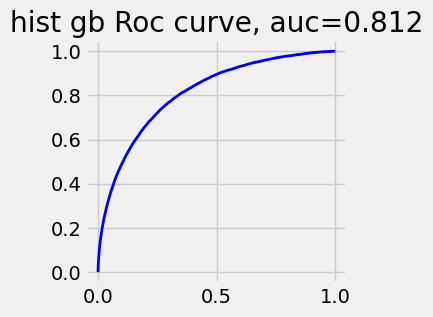

In [165]:
train_prob = hist_gradient_boost_model.predict_proba(train_features)
plot_roc(train_labels, train_prob[:,1], 'hist gb')


In [166]:
import time
import os

def submit(ids, pred, name, feature_count=None):
    """
    ids: 测试集的 SK_ID_CURR
    pred: 模型预测概率
    name: 你的实验备注 (如 'lgb_v1', 'baseline')
    feature_count: 可选，记录模型使用了多少个特征
    """
    # 1. 创建提交 DataFrame
    submit_df = pd.DataFrame({
        'SK_ID_CURR': ids,
        'TARGET': pred
    })

    # 2. 生成时间戳 (格式: 0213_1530)
    timestamp = time.strftime("%m%d_%H%M")
    
    # 3. 构造文件名
    # 格式: 0213_1530_lgb_v1_f542.csv
    f_str = f"_f{feature_count}" if feature_count else ""
    filename = f"{timestamp}_{name}{f_str}.csv"
    
    # 4. 确保保存目录存在 (可选)
    if not os.path.exists('submissions'):
        os.makedirs('submissions')
    
    save_path = os.path.join('submissions', filename)
    
    # 5. 保存并打印提示
    submit_df.to_csv(save_path, index=False)
    
    return submit_df


In [167]:
submit_df = submit(test['SK_ID_CURR'], hist_gradient_boost_model_pred[:, 1], 
    name='hgbm_baseline',
    feature_count=train_features.shape[1]
    )
submit_df


,SK_ID_CURR,TARGET
0,100001,0.041575
1,100005,0.161436
2,100013,0.020080
3,100028,0.029833
4,100038,0.178684
...,...,...
48739,456221,0.067602
48740,456222,0.085417
48741,456223,0.022706
48742,456224,0.053502


得分 74， 有点不太合理

#### lightbgm

In [168]:
train_features_cleaned = clean_names(train_features)
test_features_cleaned = clean_names(test_features)

In [169]:
%%time
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(
    n_estimators=100,      # 对应 max_iter，树的个数
    learning_rate=0.1,     # 学习率
    max_depth=3,           # 树的最大深度
    random_state=42,       # 保证结果可复现
    n_jobs=-1              # 使用所有 CPU 核心加速
)
lgbm_model.fit(train_features_cleaned, train_labels)

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.102541 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 73666
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 1058
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,3
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [170]:
lgbm_model_pred = lgbm_model.predict_proba(test_features_cleaned)[:, 1]

In [171]:
submit_df = submit(test['SK_ID_CURR'], lgbm_model_pred, 
    name='lgbm_baseline',
    feature_count=train_features.shape[1]
    )
submit_df


,SK_ID_CURR,TARGET
0,100001,0.055758
1,100005,0.142900
2,100013,0.029373
3,100028,0.034231
4,100038,0.148776
...,...,...
48739,456221,0.042909
48740,456222,0.063323
48741,456223,0.028442
48742,456224,0.048157


In [172]:
features_importance = pd.DataFrame(
    {
        'importance': lgbm_model.feature_importances_,
        'feature': lgbm_model.feature_name_
    }
)

In [173]:
def plot_features_importance(df):
    df = df.sort_values(by='importance', ascending=False).head(20)
    plt.figure(figsize=(10,6))
    sns.barplot(
        data = df,
        x= 'importance',
        y = 'feature'
    )
    plt.tight_layout()

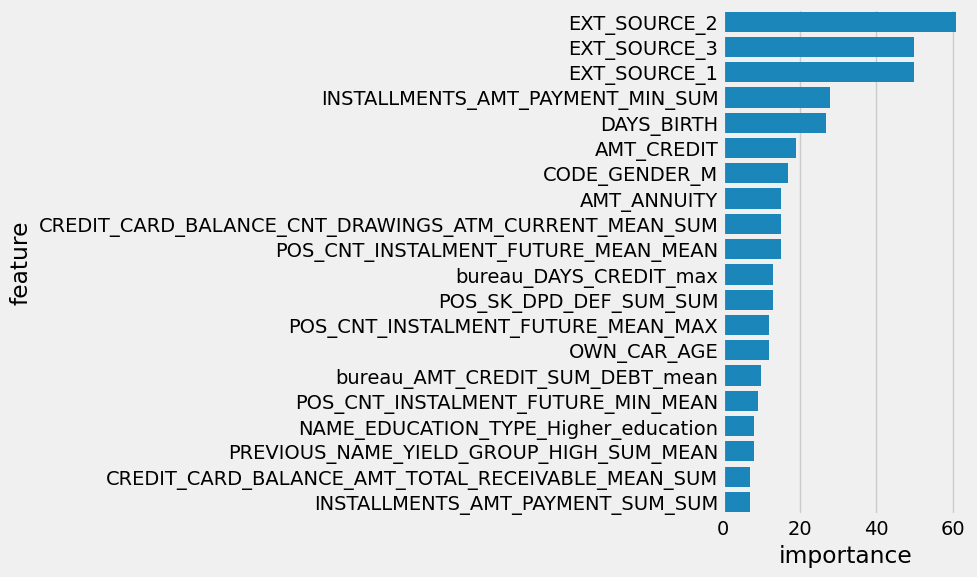

In [174]:
plot_features_importance(features_importance)

可以看到，我们很多特征都有效了。

得分 74